In [1]:
#from expand_peaks import *
import os
import pandas as pd

#Make training sequences 
def expand_peaks_summit(bed_dir,output_dir,expand_width):
    bed = pd.read_csv(bed_dir,sep="\t",header=None)
    bed["summit"]=bed[1]+bed[9]
    bed["start"] = bed["summit"]-expand_width/2+1
    bed["end"] = bed["summit"] + expand_width/2+1
    bed["start"] = bed["start"].astype(int)
    bed["end"] = bed["end"].astype(int)
    bed[[0,"start","end",3,4,5,6,7,8,9]].to_csv(output_dir,index=False, sep="\t",header=None)

#Make training sequences 
def expand_peaks_summit_log(bed_dir,output_dir,expand_width):
    bed = pd.read_csv(bed_dir,sep="\t",header=None)
    bed["summit"]=bed[1]+bed[9]
    bed["start"] = bed["summit"]-expand_width/2+1
    bed["end"] = bed["summit"] + expand_width/2+1
    bed["start"] = bed["start"].astype(int)
    bed["end"] = bed["end"].astype(int)
    bed[6]=np.log()
    bed[[0,"start","end",3,4,5,6,7,8,9]].to_csv(output_dir,index=False, sep="\t",header=None)

def split_train_val_dataset(input_file, train_file, val_file, test_file,expand_width):
    # Read the input file into a DataFrame
    df = pd.read_csv(input_file, sep="\t", header=None)

    # Splitting the DataFrame into validation and test sets based on chromosome numbers
    val = df[df[0] == "chr4"]
    test = df[(df[0] == "chr8") | (df[0] == "chr9")]

    # The training set is what's left after removing validation and test sets
    train = df.drop(val.index).drop(test.index)

    # Write the subsets to their respective files
    val.to_csv(val_file, sep="\t", header=None, index=None)
    test.to_csv(test_file, sep="\t", header=None, index=None)
    train.to_csv(train_file, sep="\t", header=None, index=None)

    # Assuming expand_peaks_summit is a function you have defined elsewhere
    for file in [train_file, val_file, test_file]:
        expand_peaks_summit(file, file,expand_width)



<Axes: >

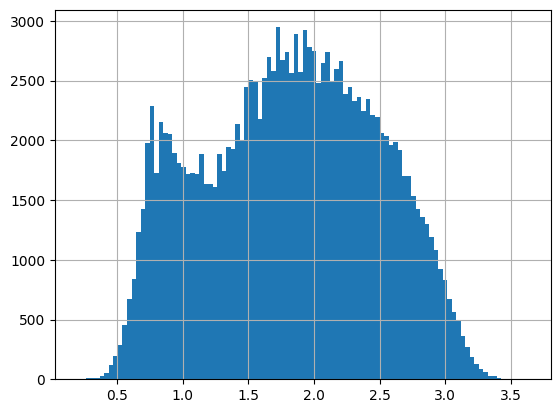

In [ ]:
import pandas as pd 
import numpy as np
df = pd.read_csv('/media/zihengc/T7/THP1_machinelearning/peak_files/LPSIFNG_4hrs/THP1_LPSIFNG_4hrs.idr.optimal_peak.narrowPeak.gz',sep='\t',header=None)
np.log(df[6]).hist(bins=100)

In [3]:
import pandas as pd
import numpy as np

def quantile_normalize(series):
    # Step 1: Sort the values
    sorted_series = series.sort_values()
    
    # Step 2: Compute the rank
    rank = sorted_series.rank(method='average')
    
    # Step 3: Compute the quantile
    quantile = rank / len(series)
    
    # Step 4: Get the quantile values from a standard normal distribution
    norm = np.random.normal(loc=0, scale=1, size=len(series))
    norm.sort()
    
    # Step 5: Replace the original values with the quantile values
    normalized_values = pd.Series(norm, index=sorted_series.index)
    
    return normalized_values




In [9]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
One-click pipeline (Python 3.7 compatible) that reproduces your *old outputs*:

NEG outputs in {neg_out_dir}/ (same naming as before):
  {name}.expand_{W}bp_hg38_biasaway_GCmatch_background.fasta
  {name}.expand_{W}bp_hg38_biasaway_GCmatch_background_noOverlap.fasta
  {name}.expand_{W}bp_hg38_biasaway_GCmatch_background_noOverlap_validation.fasta
  {name}.expand_{W}bp_hg38_biasaway_GCmatch_background_noOverlap_test.fasta
  {name}.expand_{W}bp_hg38_biasaway_GCmatch_background_noOverlap_train.fasta

POS expanded BED/FASTA:
  {expand_bed_dir}/{name}.expand_{W}bp_hg38.bed
  {pos_fasta_dir}/{name}.expand_{W}bp_hg38.fasta
  {expand_bed_dir}/{name}.narrowPeak.train.bed (+ validation/test)
  {pos_fasta_dir}/{name}.narrowPeak.train.bed.fasta (+ validation/test)

Old-style NEG bed splits (same as your separate_negatives()):
  {expand_bed_dir}/{name}.narrowPeak.train.withNeg.bed (+ validation/test)
  {expand_bed_dir}/{name}.narrowPeak.train.Neg.bed (+ validation/test)
  {expand_bed_dir}/{name}.narrowPeak.train.Neg_Part1.bed ... Part4

POSNEG FASTA (optional, same style as you did with cat):
  {posneg_out_dir}/{name}.narrowPeak.train.posneg.fasta (+ validation/test)

Edit CONFIG at bottom to switch datasets quickly.
"""

import os
import gzip
import glob
import shutil
import subprocess
from pathlib import Path
from typing import Optional
import pandas as pd


# =========================================================
# 0) helpers
# =========================================================
def require_file(p: str, label: str = ""):
    pth = Path(p)
    if not pth.is_file():
        raise FileNotFoundError(f"{label} missing file: {pth}")

def require_dir(p: str, label: str = ""):
    pth = Path(p)
    if not pth.is_dir():
        raise FileNotFoundError(f"{label} missing dir: {pth}")

def ensure_dir(p: str):
    Path(p).mkdir(parents=True, exist_ok=True)

def which_or_raise(exe: str):
    if shutil.which(exe) is None:
        raise EnvironmentError(f"Missing executable in PATH: {exe}")

def run(cmd: str):
    subprocess.run(cmd, shell=True, check=True)

def gunzip_to_temp(gz_path: str, out_path: str):
    with gzip.open(gz_path, "rb") as f_in, open(out_path, "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)

def maybe_decompress(path_in: str, work_dir: str) -> str:
    p = Path(path_in)
    if p.suffix == ".gz":
        out_path = str(Path(work_dir) / p.name.replace(".gz", ""))
        gunzip_to_temp(str(p), out_path)
        return out_path
    return str(p)

def neg_paths(neg_out_dir: str, name: str, expand_width: int):
    """
    Produce negative output paths matching your old convention.
    """
    base = f"{name}.expand_{expand_width}bp_hg38_biasaway_GCmatch_background"
    outdir = Path(neg_out_dir)
    return {
        "base": base,
        "background": str(outdir / f"{base}.fasta"),
        "nooverlap": str(outdir / f"{base}_noOverlap.fasta"),
        "val": str(outdir / f"{base}_noOverlap_validation.fasta"),
        "test": str(outdir / f"{base}_noOverlap_test.fasta"),
        "train": str(outdir / f"{base}_noOverlap_train.fasta"),
    }


# =========================================================
# 1) POS: expand summit from narrowPeak -> BED
# =========================================================
def expand_peaks_summit(narrowpeak_in: str, bed_out: str, expand_width: int):
    """
    narrowPeak columns (>=10):
      0 chrom, 1 start, 2 end, 3 name, 4 score, 5 strand,
      6 signalValue, 7 pValue, 8 qValue, 9 summit offset
    Outputs 10 columns, with start/end replaced by summit-centered window.

    Uses BED 0-based convention: start inclusive, end exclusive.
    """
    df = pd.read_csv(narrowpeak_in, sep="\t", header=None)
    if df.shape[1] < 10:
        raise ValueError(f"{narrowpeak_in} has {df.shape[1]} cols; expected >=10 for narrowPeak.")

    summit = df[1] + df[9]
    half = int(expand_width) // 2
    df["start"] = (summit - half).astype(int)
    df["end"] = (summit + half).astype(int)
    df.loc[df["start"] < 0, "start"] = 0

    out = df[[0, "start", "end", 3, 4, 5, 6, 7, 8, 9]]
    ensure_dir(str(Path(bed_out).parent))
    out.to_csv(bed_out, sep="\t", header=None, index=False)


def split_train_val_dataset(input_narrowpeak: str, train_bed: str, val_bed: str, test_bed: str, expand_width: int):
    """
    val = chr4
    test = chr8 or chr9
    train = remaining
    Then expand around summit to fixed width (in place).
    """
    df = pd.read_csv(input_narrowpeak, sep="\t", header=None)
    val = df[df[0] == "chr4"].copy()
    test = df[(df[0] == "chr8") | (df[0] == "chr9")].copy()
    train = df.drop(val.index).drop(test.index).copy()

    ensure_dir(str(Path(train_bed).parent))
    val.to_csv(val_bed, sep="\t", header=None, index=False)
    test.to_csv(test_bed, sep="\t", header=None, index=False)
    train.to_csv(train_bed, sep="\t", header=None, index=False)

    for f in [train_bed, val_bed, test_bed]:
        expand_peaks_summit(f, f, expand_width)


# =========================================================
# 2) NEG: FASTA parsing + overlap removal
# =========================================================
def parse_fasta_to_dataframe_biasaway(fasta_file: str) -> pd.DataFrame:
    """
    Parse biasaway-like headers: >chr1_12345_...
    """
    chromosomes, starts, ends, sequences = [], [], [], []
    current_seq = ""
    current_header = ""

    with open(fasta_file, "r") as f:
        for line in f:
            if line.startswith(">"):
                if current_seq:
                    parts = current_header.split("_")
                    try:
                        s = int(parts[1])
                        chromosomes.append(parts[0][1:])
                        starts.append(s)
                        ends.append(s + 500)
                        sequences.append(current_seq)
                    except ValueError:
                        pass
                    current_seq = ""
                current_header = line.strip()
            else:
                current_seq += line.strip()

        if current_seq:
            parts = current_header.split("_")
            try:
                s = int(parts[1])
                chromosomes.append(parts[0][1:])
                starts.append(s)
                ends.append(s + 499)
                sequences.append(current_seq)
            except ValueError:
                pass

    return pd.DataFrame({"chromosome": chromosomes, "start": starts, "end": ends, "sequence": sequences})


def parse_fasta_to_dataframe_bedtools(fasta_file: str) -> pd.DataFrame:
    """
    Parse bedtools getfasta headers: >chr1:123-623
    """
    chromosomes, starts, ends, sequences = [], [], [], []
    current_seq = ""
    current_header = ""

    with open(fasta_file, "r") as f:
        for line in f:
            if line.startswith(">"):
                if current_seq:
                    h = current_header[1:]
                    chrom, coord = h.split(":")
                    s, e = coord.split("-")
                    chromosomes.append(chrom)
                    starts.append(int(s))
                    ends.append(int(e))
                    sequences.append(current_seq)
                    current_seq = ""
                current_header = line.strip()
            else:
                current_seq += line.strip()

        if current_seq:
            h = current_header[1:]
            chrom, coord = h.split(":")
            s, e = coord.split("-")
            chromosomes.append(chrom)
            starts.append(int(s))
            ends.append(int(e))
            sequences.append(current_seq)

    return pd.DataFrame({"chromosome": chromosomes, "start": starts, "end": ends, "sequence": sequences})


def dataframe_to_bed(df: pd.DataFrame, filename: str):
    bed_df = df[["chromosome", "start", "end"]].copy()
    bed_df["start"] = bed_df["start"] - 1  # to 0-based
    bed_df.to_csv(filename, sep="\t", header=False, index=False)

def parse_bed_to_dataframe(bed_file: str) -> pd.DataFrame:
    df = pd.read_csv(bed_file, sep="\t", header=None, names=["chromosome", "start", "end"])
    df["start"] = df["start"] + 1  # back to 1-based for merge
    return df

def dataframe_to_fasta(df: pd.DataFrame, fasta_file: str):
    ensure_dir(str(Path(fasta_file).parent))
    with open(fasta_file, "w") as f:
        for _, row in df.iterrows():
            f.write(f">{row['chromosome']}:{row['start']}-{row['end']}\n{row['sequence']}\n")

def remove_matching_sequences(df_neg: pd.DataFrame, df_pos: pd.DataFrame) -> pd.DataFrame:
    pos_seqs = set(df_pos["sequence"])
    return df_neg[~df_neg["sequence"].isin(pos_seqs)].copy()


def process_fasta_files(
    fasta_file_neg: str,
    fasta_file_pos: str,
    peak_file_pos: str,
    output_fasta_file: str,
    tmp_prefix: str = "tmp_nooverlap"
):
    """
    1) Parse neg fasta, dedup sequences
    2) bedtools intersect -v to remove overlaps by coordinates with peak_file_pos
    3) Parse pos fasta and remove exact-sequence duplicates
    4) Write filtered neg fasta
    """
    df_neg = parse_fasta_to_dataframe_biasaway(fasta_file_neg).drop_duplicates("sequence")
    df_pos = parse_fasta_to_dataframe_bedtools(fasta_file_pos)

    bed_a = f"{tmp_prefix}.neg.bed"
    bed_out = f"{tmp_prefix}.neg_no_overlap.bed"

    dataframe_to_bed(df_neg, bed_a)
    run(f"bedtools intersect -a {bed_a} -b {peak_file_pos} -v > {bed_out}")

    df_no_ol = parse_bed_to_dataframe(bed_out)
    df_filtered = df_neg.merge(df_no_ol, on=["chromosome", "start", "end"], how="inner")
    df_filtered = remove_matching_sequences(df_filtered, df_pos)

    dataframe_to_fasta(df_filtered, output_fasta_file)

    for f in [bed_a, bed_out]:
        if Path(f).exists():
            os.remove(f)


def parse_fasta(fasta_file: str) -> pd.DataFrame:
    """
    Parse >chr:start-end to DataFrame with columns: chr,start,end,sequence (start/end as strings).
    """
    sequences, chrs, starts, ends = [], [], [], []
    seq = ""
    with open(fasta_file, "r") as f:
        for line in f:
            if line.startswith(">"):
                if seq:
                    sequences.append(seq)
                    seq = ""
                header = line[1:].strip().split(":")
                rng = header[1].split("-")
                chrs.append(header[0])
                starts.append(rng[0])
                ends.append(rng[1])
            else:
                seq += line.strip()
        if seq:
            sequences.append(seq)
    return pd.DataFrame({"chr": chrs, "start": starts, "end": ends, "sequence": sequences})

def df_to_fasta(df: pd.DataFrame, output_file: str):
    ensure_dir(str(Path(output_file).parent))
    with open(output_file, "w") as f:
        for _, row in df.iterrows():
            f.write(f">{row['chr']}:{row['start']}-{row['end']}\n{row['sequence']}\n")


# =========================================================
# 2.5) OLD behavior: add negatives to pos beds + split Neg_Part1..4
# =========================================================
def separate_negatives(narrowpeak_list, order):
    """
    Reproduce your old outputs:
      - *.withNeg.bed
      - *.Neg.bed
      - train only: *.Neg_Part1..4.bed
    """
    for i, narrowpeak_file in enumerate(narrowpeak_list):
        df_tmp = pd.read_csv(narrowpeak_file, sep="\t", header=None)

        current_neg = order[i][["chr", "start", "end"]].copy()
        current_neg["start"] = current_neg["start"].astype(int)
        current_neg["end"] = current_neg["end"].astype(int)

        current_neg[6] = 0
        current_neg.columns = [0, 1, 2, 6]
        current_neg[[3, 4, 5, 7, 8, 9]] = "NA"
        current_neg = current_neg[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]]

        # withNeg
        pd.concat([df_tmp, current_neg]).to_csv(
            narrowpeak_file[:-4] + ".withNeg.bed",
            sep="\t", header=None, index=False
        )

        # Neg only
        current_neg.to_csv(
            narrowpeak_file[:-4] + ".Neg.bed",
            sep="\t", header=None, index=False
        )

        # Neg parts for train
        if narrowpeak_file.endswith("train.bed"):
            data_shuffled = current_neg.sample(frac=1, random_state=0).reset_index(drop=True)
            split_size = len(data_shuffled) // 4

            part1 = data_shuffled.iloc[:split_size]
            part2 = data_shuffled.iloc[split_size:2 * split_size]
            part3 = data_shuffled.iloc[2 * split_size:3 * split_size]
            part4 = data_shuffled.iloc[3 * split_size:]

            remaining_rows = len(data_shuffled) % 4
            if remaining_rows:
                part4 = pd.concat([part4, data_shuffled.iloc[-remaining_rows:]])

            parts = [part1, part2, part3, part4]
            for j, part in enumerate(parts, start=1):
                part.to_csv(
                    narrowpeak_file[:-4] + f".Neg_Part{j}.bed",
                    sep="\t", header=None, index=False
                )


# =========================================================
# 3) all_possible_peaks merged + expand each side
# =========================================================
def build_all_possible_merged_expand(all_possible_glob: str, work_dir: str, prefix: str, expand_each_side: int):
    ensure_dir(work_dir)

    files = sorted(glob.glob(all_possible_glob))
    if len(files) == 0:
        raise FileNotFoundError(f"No files matched: {all_possible_glob}")

    cated = str(Path(work_dir) / f"{prefix}_all_possible_peaks.narrowPeak")
    merged = str(Path(work_dir) / f"{prefix}_all_possible_peaks_merged.bed")
    expanded = str(Path(work_dir) / f"{prefix}_all_possible_peaks_merged_expand{expand_each_side}bp_eachside.bed")

    # concatenate into one text narrowPeak (decompress if needed)
    with open(cated, "wb") as out:
        for fp in files:
            p = Path(fp)
            if p.suffix == ".gz":
                with gzip.open(fp, "rb") as f_in:
                    shutil.copyfileobj(f_in, out)
            else:
                with open(fp, "rb") as f_in:
                    shutil.copyfileobj(f_in, out)

    run(f"bedtools sort -i {cated} | bedtools merge -d 200 -i - > {merged}")

    # expand each side: start-N, end+N (clamp start>=0)
    df = pd.read_csv(merged, sep="\t", header=None)
    df[1] = (df[1].astype(int) - int(expand_each_side)).clip(lower=0)
    df[2] = (df[2].astype(int) + int(expand_each_side))
    df[[0, 1, 2]].to_csv(expanded, sep="\t", header=None, index=False)

    return merged, expanded


# =========================================================
# 4) biasaway auto-run if background missing
# =========================================================
def run_biasaway_if_needed(
    foreground_fa: str,
    background_fa: str,
    bgdir: str,
    seed: int = 19951124,
    plot_dir: Optional[str] = None,
):
    outp = Path(background_fa)
    if outp.is_file():
        print("[SKIP] biasaway background exists:", background_fa)
        return

    which_or_raise("biasaway")
    require_dir(bgdir, label="biasaway_bgdir")
    ensure_dir(str(outp.parent))

    cmd = f"biasaway g --foreground {foreground_fa} --nfold 1 --bgdirectory {bgdir} --seed {seed}"
    if plot_dir:
        ensure_dir(plot_dir)
        cmd += f" --plot_filename {plot_dir}"
    cmd += f" > {background_fa}"

    print("[RUN] ", cmd)
    run(cmd)
    require_file(background_fa, label="biasaway_output")


# =========================================================
# 5) validation
# =========================================================
def validate_config(cfg: dict):
    require_file(cfg["narrowpeak_gz"], "CONFIG")
    require_file(cfg["genome_fa"], "CONFIG")
    require_dir(cfg["biasaway_bgdir"], "CONFIG")
    require_dir(cfg["neg_out_dir"], "CONFIG (neg_out_dir must exist)")

    ensure_dir(cfg["work_dir"])
    ensure_dir(cfg["expand_bed_dir"])
    ensure_dir(cfg["pos_fasta_dir"])
    ensure_dir(cfg["posneg_out_dir"])

    which_or_raise("bedtools")
    negp = neg_paths(cfg["neg_out_dir"], cfg["name"], int(cfg["expand_width"]))
    if not Path(negp["background"]).is_file():
        which_or_raise("biasaway")


# =========================================================
# 6) main
# =========================================================
def main(cfg: dict):
    validate_config(cfg)

    name = cfg["name"]
    expand_width = int(cfg["expand_width"])
    negp = neg_paths(cfg["neg_out_dir"], name, expand_width)

    # ----------------------------
    # A) POS full: expand + fasta
    # ----------------------------
    narrowpeak_txt = maybe_decompress(cfg["narrowpeak_gz"], cfg["work_dir"])

    pos_full_bed = str(Path(cfg["expand_bed_dir"]) / f"{name}.expand_{expand_width}bp_hg38.bed")
    pos_full_fa = str(Path(cfg["pos_fasta_dir"]) / f"{name}.expand_{expand_width}bp_hg38.fasta")

    expand_peaks_summit(narrowpeak_txt, pos_full_bed, expand_width)
    run(f"bedtools getfasta -fi {cfg['genome_fa']} -bed {pos_full_bed} > {pos_full_fa}")

    # ----------------------------
    # B) POS split: beds + fastas
    # ----------------------------
    pos_train_bed = str(Path(cfg["expand_bed_dir"]) / f"{name}.narrowPeak.train.bed")
    pos_val_bed = str(Path(cfg["expand_bed_dir"]) / f"{name}.narrowPeak.validation.bed")
    pos_test_bed = str(Path(cfg["expand_bed_dir"]) / f"{name}.narrowPeak.test.bed")

    split_train_val_dataset(narrowpeak_txt, pos_train_bed, pos_val_bed, pos_test_bed, expand_width)

    pos_train_fa = str(Path(cfg["pos_fasta_dir"]) / (Path(pos_train_bed).name + ".fasta"))
    pos_val_fa = str(Path(cfg["pos_fasta_dir"]) / (Path(pos_val_bed).name + ".fasta"))
    pos_test_fa = str(Path(cfg["pos_fasta_dir"]) / (Path(pos_test_bed).name + ".fasta"))

    run(f"bedtools getfasta -fi {cfg['genome_fa']} -bed {pos_train_bed} > {pos_train_fa}")
    run(f"bedtools getfasta -fi {cfg['genome_fa']} -bed {pos_val_bed} > {pos_val_fa}")
    run(f"bedtools getfasta -fi {cfg['genome_fa']} -bed {pos_test_bed} > {pos_test_fa}")

    # ----------------------------
    # C) biasaway background (write to neg_out_dir with your naming)
    # ----------------------------
    run_biasaway_if_needed(
        foreground_fa=pos_full_fa,
        background_fa=negp["background"],
        bgdir=cfg["biasaway_bgdir"],
        seed=int(cfg.get("biasaway_seed", 19951124)),
        plot_dir=cfg.get("biasaway_plot_dir", None),
    )

    # ----------------------------
    # D) all_possible peaks merged + expanded (for overlap removal)
    # ----------------------------
    _, peak_file_pos = build_all_possible_merged_expand(
        all_possible_glob=cfg["all_possible_glob"],
        work_dir=cfg["work_dir"],
        prefix=name,
        expand_each_side=int(cfg["expand_each_side_for_nooverlap"]),
    )

    # ----------------------------
    # E) NEG filter -> noOverlap fasta (your naming) then split (val/test/train fasta)
    # ----------------------------
    process_fasta_files(
        fasta_file_neg=negp["background"],
        fasta_file_pos=pos_full_fa,
        peak_file_pos=peak_file_pos,
        output_fasta_file=negp["nooverlap"],
        tmp_prefix=str(Path(cfg["work_dir"]) / f"{name}.tmp"),
    )
    require_file(negp["nooverlap"], "noOverlap output")

    df_neg = parse_fasta(negp["nooverlap"])
    val = df_neg[df_neg["chr"] == "chr4"].copy()
    test = df_neg[(df_neg["chr"] == "chr8") | (df_neg["chr"] == "chr9")].copy()
    train = df_neg[~df_neg["chr"].isin(["chr4", "chr8", "chr9"])].copy()

    df_to_fasta(val, negp["val"])
    df_to_fasta(test, negp["test"])
    df_to_fasta(train, negp["train"])

    # ----------------------------
    # F) OLD outputs: .withNeg/.Neg/.Neg_Part1..4 written next to the POS split beds
    # ----------------------------
    narrowpeak_list = [pos_train_bed, pos_val_bed, pos_test_bed]
    order = [train, val, test]
    separate_negatives(narrowpeak_list, order)

    # ----------------------------
    # G) POSNEG cat outputs (match your previous naming)
    # ----------------------------
    ensure_dir(cfg["posneg_out_dir"])
    out_titles = [
        str(Path(cfg["posneg_out_dir"]) / f"{name}.narrowPeak.validation.posneg.fasta"),
        str(Path(cfg["posneg_out_dir"]) / f"{name}.narrowPeak.test.posneg.fasta"),
        str(Path(cfg["posneg_out_dir"]) / f"{name}.narrowPeak.train.posneg.fasta"),
    ]
    neg_fastas = [negp["val"], negp["test"], negp["train"]]
    pos_fastas = [pos_val_fa, pos_test_fa, pos_train_fa]  # keep same order as your old code

    for pos_fa, neg_fa, out_fa in zip(pos_fastas, neg_fastas, out_titles):
        run(f"cat {pos_fa} {neg_fa} > {out_fa}")

    print("\n[DONE]")
    print("NEG outputs (old naming):")
    for k in ["background", "nooverlap", "val", "test", "train"]:
        print(" ", k, "=", negp[k])
    print("POS split beds:", pos_train_bed, pos_val_bed, pos_test_bed)
    print("Generated:", pos_train_bed[:-4] + ".Neg_Part1.bed ... Neg_Part4.bed")
    print("POSNEG outputs:", out_titles)
    print("Overlap-filter peak bed used:", peak_file_pos)


# =========================================================
# 7) EDIT HERE ONLY
# =========================================================
CONFIG = {
    # prefix used in all outputs
    "name": "fullard_DLPFC_neurons.optimal_peak",

    # primary positive narrowPeak (.gz ok)
    "narrowpeak_gz": "../peak_files/fullard_DLPFC/fullard_DLPFC_neurons.optimal_peak.narrowPeak.gz",

    # hg38 fasta
    "genome_fa": "../../genome/hg38.fa",

    # expansion width around summit for model sequences
    "expand_width": 500,

    # biasaway background directory (must exist)
    "biasaway_bgdir": "../hg38_500bp_biasaway_background",
    "biasaway_seed": 19951124,
    "biasaway_plot_dir": "biasaway_figures/fullard_DLPFC/",  # set to None or "" to disable

    # all possible peaks for overlap filtering
    "all_possible_glob": "../peak_files/fullard_DLPFC/*.narrowPeak.gz",
    "expand_each_side_for_nooverlap": 500,

    # output directories
    "work_dir": "./_work_fullard_DLPFC",
    "expand_bed_dir": "../expand_peaks_500bp_hg38",
    "pos_fasta_dir": "../expand_peaks_500bp_fasta_hg38",

    # IMPORTANT: neg_out_dir must exist
    "neg_out_dir": "/media/zihengc/T7/THP1_machinelearning/background_negatives_500bp_hg38",

    "posneg_out_dir": "../positive_negative_500bp_hg38",
}


if __name__ == "__main__":
    main(CONFIG)

OSError: [Errno 5] Input/output error: '../peak_files/fullard_DLPFC/fullard_DLPFC_neurons.optimal_peak.narrowPeak.gz'

In [5]:
# =========================================================
# 7) EDIT HERE ONLY
# =========================================================
CONFIG = {
    # NOTE: keep this as the "prefix" you want in filenames
    "name": "fullard_putaman_neurons.optimal_peak",

    # primary positive narrowPeak (.gz ok)
    "narrowpeak_gz": "/media/zihengc/T7/THP1_machinelearning/peak_files/fullard_putaman/fullard_putaman_neurons_optimal_peak.narrowPeak.gz",

    # hg38 fasta
    "genome_fa": "/media/zihengc/T7/genome/hg38.fa",

    # expansion width around summit for model sequences
    "expand_width": 500,

    # biasaway background directory (must exist)
    "biasaway_bgdir": "/media/zihengc/T7/THP1_machinelearning/hg38_500bp_biasaway_background",
    "biasaway_seed": 19951124,
    "biasaway_plot_dir": "/media/zihengc/T7/THP1_machinelearning/biasaway_figures/fullard_putaman/",  # set to None or "" to disable

    # all possible peaks for overlap filtering
    "all_possible_glob": "/media/zihengc/T7/THP1_machinelearning/peak_files/fullard_putaman/*.narrowPeak.gz",
    "expand_each_side_for_nooverlap": 500,

    # output directories
    "work_dir": "/media/zihengc/T7/THP1_machinelearning/_work_fullard_putaman",
    "expand_bed_dir": "/media/zihengc/T7/THP1_machinelearning/expand_peaks_500bp_hg38",
    "pos_fasta_dir": "/media/zihengc/T7/THP1_machinelearning/expand_peaks_500bp_fasta_hg38",

    # IMPORTANT: set to your desired NEG output folder
    "neg_out_dir": "/media/zihengc/T7/THP1_machinelearning/background_negatives_500bp_hg38",

    "posneg_out_dir": "/media/zihengc/T7/THP1_machinelearning/positive_negative_500bp_hg38",
}


if __name__ == "__main__":
    main(CONFIG)

[RUN]  biasaway g --foreground /media/zihengc/T7/THP1_machinelearning/expand_peaks_500bp_fasta_hg38/fullard_putaman_neurons.optimal_peak.expand_500bp_hg38.fasta --nfold 1 --bgdirectory /media/zihengc/T7/THP1_machinelearning/hg38_500bp_biasaway_background --seed 19951124 --plot_filename /media/zihengc/T7/THP1_machinelearning/biasaway_figures/fullard_putaman/ > /media/zihengc/T7/THP1_machinelearning/background_negatives_500bp_hg38/fullard_putaman_neurons.optimal_peak.expand_500bp_hg38_biasaway_GCmatch_background.fasta

[DONE]
NEG outputs (matched naming):
  background: /media/zihengc/T7/THP1_machinelearning/background_negatives_500bp_hg38/fullard_putaman_neurons.optimal_peak.expand_500bp_hg38_biasaway_GCmatch_background.fasta
  noOverlap : /media/zihengc/T7/THP1_machinelearning/background_negatives_500bp_hg38/fullard_putaman_neurons.optimal_peak.expand_500bp_hg38_biasaway_GCmatch_background_noOverlap.fasta
  val/test/train: /media/zihengc/T7/THP1_machinelearning/background_negatives_500b

In [6]:
# =========================================================
# 7) EDIT HERE ONLY
# =========================================================
CONFIG = {
    # prefix used in output filenames
    "name": "fullard_hippocampus_neurons.optimal_peak",

    # primary positive narrowPeak (.gz ok)
    "narrowpeak_gz": "/media/zihengc/T7/THP1_machinelearning/peak_files/fullard_hippocampus/fullard_hippocampus_neurons.optimal_peak.narrowPeak.gz",

    # hg38 fasta
    "genome_fa": "/media/zihengc/T7/genome/hg38.fa",

    # expansion width around summit for model sequences
    "expand_width": 500,

    # biasaway background directory (must exist)
    "biasaway_bgdir": "/media/zihengc/T7/THP1_machinelearning/hg38_500bp_biasaway_background",
    "biasaway_seed": 19951124,
    "biasaway_plot_dir": "/media/zihengc/T7/THP1_machinelearning/biasaway_figures/fullard_hippocampus/",  # set to None or "" to disable

    # all possible peaks for overlap filtering
    "all_possible_glob": "/media/zihengc/T7/THP1_machinelearning/peak_files/fullard_hippocampus/*.narrowPeak.gz",
    "expand_each_side_for_nooverlap": 500,

    # output directories
    "work_dir": "/media/zihengc/T7/THP1_machinelearning/_work_fullard_hippocampus",
    "expand_bed_dir": "/media/zihengc/T7/THP1_machinelearning/expand_peaks_500bp_hg38",
    "pos_fasta_dir": "/media/zihengc/T7/THP1_machinelearning/expand_peaks_500bp_fasta_hg38",

    # NEG outputs
    "neg_out_dir": "/media/zihengc/T7/THP1_machinelearning/background_negatives_500bp_hg38",

    # POSNEG outputs
    "posneg_out_dir": "/media/zihengc/T7/THP1_machinelearning/positive_negative_500bp_hg38",
}

if __name__ == "__main__":
    main(CONFIG)

Feature (chrUn_KI270438v1:112143-112643) beyond the length of chrUn_KI270438v1 size (112505 bp).  Skipping.
Feature (chrUn_KI270466v1:801-1301) beyond the length of chrUn_KI270466v1 size (1233 bp).  Skipping.
Feature (chrUn_KI270438v1:112143-112643) beyond the length of chrUn_KI270438v1 size (112505 bp).  Skipping.
Feature (chrUn_KI270466v1:801-1301) beyond the length of chrUn_KI270466v1 size (1233 bp).  Skipping.


[RUN]  biasaway g --foreground /media/zihengc/T7/THP1_machinelearning/expand_peaks_500bp_fasta_hg38/fullard_hippocampus_neurons.optimal_peak.expand_500bp_hg38.fasta --nfold 1 --bgdirectory /media/zihengc/T7/THP1_machinelearning/hg38_500bp_biasaway_background --seed 19951124 --plot_filename /media/zihengc/T7/THP1_machinelearning/biasaway_figures/fullard_hippocampus/ > /media/zihengc/T7/THP1_machinelearning/background_negatives_500bp_hg38/fullard_hippocampus_neurons.optimal_peak.expand_500bp_hg38_biasaway_GCmatch_background.fasta

[DONE]
NEG outputs (matched naming):
  background: /media/zihengc/T7/THP1_machinelearning/background_negatives_500bp_hg38/fullard_hippocampus_neurons.optimal_peak.expand_500bp_hg38_biasaway_GCmatch_background.fasta
  noOverlap : /media/zihengc/T7/THP1_machinelearning/background_negatives_500bp_hg38/fullard_hippocampus_neurons.optimal_peak.expand_500bp_hg38_biasaway_GCmatch_background_noOverlap.fasta
  val/test/train: /media/zihengc/T7/THP1_machinelearning/backg

In [7]:
# =========================================================
# 7) EDIT HERE ONLY
# =========================================================
CONFIG = {
    "name": "astrocyte_GSE188398.idr.optimal_peak",

    "narrowpeak_gz": "/media/zihengc/T7/THP1_machinelearning/peak_files/astrocyte_GSE188398/astrocyte_GSE188398.idr.optimal_peak.narrowPeak.gz",

    "genome_fa": "/media/zihengc/T7/genome/hg38.fa",
    "expand_width": 500,

    "biasaway_bgdir": "/media/zihengc/T7/THP1_machinelearning/hg38_500bp_biasaway_background",
    "biasaway_seed": 19951124,
    "biasaway_plot_dir": "/media/zihengc/T7/THP1_machinelearning/biasaway_figures/astrocyte_GSE188398/",  # set to None or "" to disable

    "all_possible_glob": "/media/zihengc/T7/THP1_machinelearning/peak_files/astrocyte_GSE188398/*.narrowPeak.gz",
    "expand_each_side_for_nooverlap": 500,

    "work_dir": "/media/zihengc/T7/THP1_machinelearning/_work_astrocyte_GSE188398",
    "expand_bed_dir": "/media/zihengc/T7/THP1_machinelearning/expand_peaks_500bp_hg38",
    "pos_fasta_dir": "/media/zihengc/T7/THP1_machinelearning/expand_peaks_500bp_fasta_hg38",

    "neg_out_dir": "/media/zihengc/T7/THP1_machinelearning/background_negatives_500bp_hg38",
    "posneg_out_dir": "/media/zihengc/T7/THP1_machinelearning/positive_negative_500bp_hg38",
}

if __name__ == "__main__":
    main(CONFIG)

[RUN]  biasaway g --foreground /media/zihengc/T7/THP1_machinelearning/expand_peaks_500bp_fasta_hg38/astrocyte_GSE188398.idr.optimal_peak.expand_500bp_hg38.fasta --nfold 1 --bgdirectory /media/zihengc/T7/THP1_machinelearning/hg38_500bp_biasaway_background --seed 19951124 --plot_filename /media/zihengc/T7/THP1_machinelearning/biasaway_figures/astrocyte_GSE188398/ > /media/zihengc/T7/THP1_machinelearning/background_negatives_500bp_hg38/astrocyte_GSE188398.idr.optimal_peak.expand_500bp_hg38_biasaway_GCmatch_background.fasta


*** WARNING ***
                    Sample larger than population for 77% G+C content:
                    1212 needed and 1199 obtained
*** WARNING ***
                    Sample larger than population for 85% G+C content:
                    54 needed and 46 obtained



[DONE]
NEG outputs (matched naming):
  background: /media/zihengc/T7/THP1_machinelearning/background_negatives_500bp_hg38/astrocyte_GSE188398.idr.optimal_peak.expand_500bp_hg38_biasaway_GCmatch_background.fasta
  noOverlap : /media/zihengc/T7/THP1_machinelearning/background_negatives_500bp_hg38/astrocyte_GSE188398.idr.optimal_peak.expand_500bp_hg38_biasaway_GCmatch_background_noOverlap.fasta
  val/test/train: /media/zihengc/T7/THP1_machinelearning/background_negatives_500bp_hg38/astrocyte_GSE188398.idr.optimal_peak.expand_500bp_hg38_biasaway_GCmatch_background_noOverlap_validation.fasta /media/zihengc/T7/THP1_machinelearning/background_negatives_500bp_hg38/astrocyte_GSE188398.idr.optimal_peak.expand_500bp_hg38_biasaway_GCmatch_background_noOverlap_test.fasta /media/zihengc/T7/THP1_machinelearning/background_negatives_500bp_hg38/astrocyte_GSE188398.idr.optimal_peak.expand_500bp_hg38_biasaway_GCmatch_background_noOverlap_train.fasta
POSNEG outputs:
  train: /media/zihengc/T7/THP1_machin

In [8]:
# =========================================================
# 7) EDIT HERE ONLY
# =========================================================
CONFIG = {
    "name": "oligodendrocyte_GSE143666.idr.optimal_peak",

    "narrowpeak_gz": "/media/zihengc/T7/THP1_machinelearning/peak_files/oligodendrocyte_GSE143666/oligodendrocyte_GSE143666.idr.optimal_peak.narrowPeak.gz",

    "genome_fa": "/media/zihengc/T7/genome/hg38.fa",
    "expand_width": 500,

    "biasaway_bgdir": "/media/zihengc/T7/THP1_machinelearning/hg38_500bp_biasaway_background",
    "biasaway_seed": 19951124,
    "biasaway_plot_dir": "/media/zihengc/T7/THP1_machinelearning/biasaway_figures/oligodendrocyte_GSE143666/",  # set to None or "" to disable

    "all_possible_glob": "/media/zihengc/T7/THP1_machinelearning/peak_files/oligodendrocyte_GSE143666/*.narrowPeak.gz",
    "expand_each_side_for_nooverlap": 500,

    "work_dir": "/media/zihengc/T7/THP1_machinelearning/_work_oligodendrocyte_GSE143666",
    "expand_bed_dir": "/media/zihengc/T7/THP1_machinelearning/expand_peaks_500bp_hg38",
    "pos_fasta_dir": "/media/zihengc/T7/THP1_machinelearning/expand_peaks_500bp_fasta_hg38",

    "neg_out_dir": "/media/zihengc/T7/THP1_machinelearning/background_negatives_500bp_hg38",
    "posneg_out_dir": "/media/zihengc/T7/THP1_machinelearning/positive_negative_500bp_hg38",
}

if __name__ == "__main__":
    main(CONFIG)

[RUN]  biasaway g --foreground /media/zihengc/T7/THP1_machinelearning/expand_peaks_500bp_fasta_hg38/oligodendrocyte_GSE143666.idr.optimal_peak.expand_500bp_hg38.fasta --nfold 1 --bgdirectory /media/zihengc/T7/THP1_machinelearning/hg38_500bp_biasaway_background --seed 19951124 --plot_filename /media/zihengc/T7/THP1_machinelearning/biasaway_figures/oligodendrocyte_GSE143666/ > /media/zihengc/T7/THP1_machinelearning/background_negatives_500bp_hg38/oligodendrocyte_GSE143666.idr.optimal_peak.expand_500bp_hg38_biasaway_GCmatch_background.fasta

[DONE]
NEG outputs (matched naming):
  background: /media/zihengc/T7/THP1_machinelearning/background_negatives_500bp_hg38/oligodendrocyte_GSE143666.idr.optimal_peak.expand_500bp_hg38_biasaway_GCmatch_background.fasta
  noOverlap : /media/zihengc/T7/THP1_machinelearning/background_negatives_500bp_hg38/oligodendrocyte_GSE143666.idr.optimal_peak.expand_500bp_hg38_biasaway_GCmatch_background_noOverlap.fasta
  val/test/train: /media/zihengc/T7/THP1_machine

# 500 bp

In [11]:
bed_dir = "../peak_files/WTC11_resting/WTC11resting.idr.optimal_peak.narrowPeak.gz"
output_dir = "../expand_peaks_500bp_hg38/WTC11resting.idr.optimal_peak.expand_500bp_hg38.bed"
expand_width = 500
expand_peaks_summit(bed_dir,output_dir,expand_width)
genome = "../../genome/hg38.fa"

##Get 500 bp positive sequences in fastq
import os
os.system(f"bedtools getfasta -fi {genome} -bed ../expand_peaks_500bp_hg38/WTC11resting.idr.optimal_peak.expand_500bp_hg38.bed > ../expand_peaks_500bp_fasta_hg38/WTC11resting.idr.optimal_peak.expand_500bp_hg38.fasta")

#Split a mega THP1 dataset
input_list = ["../peak_files/WTC11_resting/WTC11resting.idr.optimal_peak.narrowPeak.gz",
                "../peak_files/WTC11_resting/WTC11resting.idr.optimal_peak.narrowPeak.train.bed",
                "../peak_files/WTC11_resting/WTC11resting.idr.optimal_peak.narrowPeak.validation.bed",
                "../peak_files/WTC11_resting/WTC11resting.idr.optimal_peak.narrowPeak.test.bed"]

split_train_val_dataset(input_file=input_list[0], train_file=input_list[1], val_file=input_list[2], test_file=input_list[3],expand_width=expand_width)


for i in input_list[1:]:
    os.system("bedtools getfasta -fi {} -bed {} > {}".format(genome,i,i+".fasta"))
    fasta_dir = "../expand_peaks_500bp_fasta_hg38"
    expand_dir = "../expand_peaks_500bp_hg38"
    os.system(f"mv {i} {expand_dir}")

    os.system(f"mv {i}.fasta {fasta_dir}")
    
foreground = "../expand_peaks_500bp_fasta_hg38/WTC11resting.idr.optimal_peak.expand_500bp_hg38.fasta"
background = "../background_negatives_500bp_hg38/WTC11resting.idr.optimal_peak.expand_500bp_hg38_biasaway_GCmatch_background.fasta"
print(f"biasaway g --foreground {foreground} --nfold 1 --bgdirectory ../hg38_500bp_biasaway_background\
            --seed 19951124 --plot_filename biasaway_figures/ \
            > {background}")
                         

biasaway g --foreground ../expand_peaks_500bp_fasta_hg38/WTC11resting.idr.optimal_peak.expand_500bp_hg38.fasta --nfold 1 --bgdirectory ../hg38_500bp_biasaway_background            --seed 19951124 --plot_filename biasaway_figures/             > ../background_negatives_500bp_hg38/WTC11resting.idr.optimal_peak.expand_500bp_hg38_biasaway_GCmatch_background.fasta


In [12]:
bed_dir = "../peak_files/WTC11_stimulated/WTC11stimulated.idr.optimal_peak.narrowPeak.gz"
output_dir = "../expand_peaks_500bp_hg38/WTC11stimulated.idr.optimal_peak.expand_500bp_hg38.bed"
expand_width = 500
expand_peaks_summit(bed_dir,output_dir,expand_width)
genome = "../../genome/hg38.fa"

##Get 500 bp positive sequences in fastq
import os
os.system(f"bedtools getfasta -fi {genome} -bed ../expand_peaks_500bp_hg38/WTC11stimulated.idr.optimal_peak.expand_500bp_hg38.bed > ../expand_peaks_500bp_fasta_hg38/WTC11stimulated.idr.optimal_peak.expand_500bp_hg38.fasta")

#Split a mega THP1 dataset
input_list = ["../peak_files/WTC11_stimulated/WTC11stimulated.idr.optimal_peak.narrowPeak.gz",
                "../peak_files/WTC11_stimulated/WTC11stimulated.idr.optimal_peak.narrowPeak.train.bed",
                "../peak_files/WTC11_stimulated/WTC11stimulated.idr.optimal_peak.narrowPeak.validation.bed",
                "../peak_files/WTC11_stimulated/WTC11stimulated.idr.optimal_peak.narrowPeak.test.bed"]

split_train_val_dataset(input_file=input_list[0], train_file=input_list[1], val_file=input_list[2], test_file=input_list[3],expand_width=expand_width)


for i in input_list[1:]:
    os.system("bedtools getfasta -fi {} -bed {} > {}".format(genome,i,i+".fasta"))
    fasta_dir = "../expand_peaks_500bp_fasta_hg38"
    expand_dir = "../expand_peaks_500bp_hg38"
    os.system(f"mv {i} {expand_dir}")

    os.system(f"mv {i}.fasta {fasta_dir}")
    
foreground = "../expand_peaks_500bp_fasta_hg38/WTC11stimulated.idr.optimal_peak.expand_500bp_hg38.fasta"
background = "../background_negatives_500bp_hg38/WTC11stimulated.idr.optimal_peak.expand_500bp_hg38_biasaway_GCmatch_background.fasta"
print(f"biasaway g --foreground {foreground} --nfold 1 --bgdirectory ../hg38_500bp_biasaway_background\
            --seed 19951124 --plot_filename biasaway_figures/ \
            > {background}")
                         

biasaway g --foreground ../expand_peaks_500bp_fasta_hg38/WTC11stimulated.idr.optimal_peak.expand_500bp_hg38.fasta --nfold 1 --bgdirectory ../hg38_500bp_biasaway_background            --seed 19951124 --plot_filename biasaway_figures/             > ../background_negatives_500bp_hg38/WTC11stimulated.idr.optimal_peak.expand_500bp_hg38_biasaway_GCmatch_background.fasta


In [10]:
bed_dir = "../peak_files/H1_resting/H1resting.idr.optimal_peak.narrowPeak.gz"
output_dir = "../expand_peaks_500bp_hg38/H1resting.idr.optimal_peak.expand_500bp_hg38.bed"
expand_width = 500
expand_peaks_summit(bed_dir,output_dir,expand_width)
genome = "../../genome/hg38.fa"

##Get 500 bp positive sequences in fastq
import os
os.system(f"bedtools getfasta -fi {genome} -bed ../expand_peaks_500bp_hg38/H1resting.idr.optimal_peak.expand_500bp_hg38.bed > ../expand_peaks_500bp_fasta_hg38/H1resting.idr.optimal_peak.expand_500bp_hg38.fasta")

#Split a mega THP1 dataset
input_list = ["../peak_files/H1_resting/H1resting.idr.optimal_peak.narrowPeak.gz",
                "../peak_files/H1_resting/H1resting.idr.optimal_peak.narrowPeak.train.bed",
                "../peak_files/H1_resting/H1resting.idr.optimal_peak.narrowPeak.validation.bed",
                "../peak_files/H1_resting/H1resting.idr.optimal_peak.narrowPeak.test.bed"]

split_train_val_dataset(input_file=input_list[0], train_file=input_list[1], val_file=input_list[2], test_file=input_list[3],expand_width=expand_width)


for i in input_list[1:]:
    os.system("bedtools getfasta -fi {} -bed {} > {}".format(genome,i,i+".fasta"))
    fasta_dir = "../expand_peaks_500bp_fasta_hg38"
    expand_dir = "../expand_peaks_500bp_hg38"
    os.system(f"mv {i} {expand_dir}")

    os.system(f"mv {i}.fasta {fasta_dir}")
    
foreground = "../expand_peaks_500bp_fasta_hg38/H1resting.idr.optimal_peak.expand_500bp_hg38.fasta"
background = "../background_negatives_500bp_hg38/H1resting.idr.optimal_peak.expand_500bp_hg38_biasaway_GCmatch_background.fasta"
print(f"biasaway g --foreground {foreground} --nfold 1 --bgdirectory ../hg38_500bp_biasaway_background\
            --seed 19951124 --plot_filename biasaway_figures/ \
            > {background}")
                         

biasaway g --foreground ../expand_peaks_500bp_fasta_hg38/H1resting.idr.optimal_peak.expand_500bp_hg38.fasta --nfold 1 --bgdirectory ../hg38_500bp_biasaway_background            --seed 19951124 --plot_filename biasaway_figures/             > ../background_negatives_500bp_hg38/H1resting.idr.optimal_peak.expand_500bp_hg38_biasaway_GCmatch_background.fasta


In [9]:
bed_dir = "../peak_files/H1_stimulated/H1stimulated.idr.optimal_peak.narrowPeak.gz"
output_dir = "../expand_peaks_500bp_hg38/H1stimulated.idr.optimal_peak.expand_500bp_hg38.bed"
expand_width = 500
expand_peaks_summit(bed_dir,output_dir,expand_width)
genome = "../../genome/hg38.fa"

##Get 500 bp positive sequences in fastq
import os
os.system(f"bedtools getfasta -fi {genome} -bed ../expand_peaks_500bp_hg38/H1stimulated.idr.optimal_peak.expand_500bp_hg38.bed > ../expand_peaks_500bp_fasta_hg38/H1stimulated.idr.optimal_peak.expand_500bp_hg38.fasta")

#Split a mega THP1 dataset
input_list = ["../peak_files/H1_stimulated/H1stimulated.idr.optimal_peak.narrowPeak.gz",
                "../peak_files/H1_stimulated/H1stimulated.idr.optimal_peak.narrowPeak.train.bed",
                "../peak_files/H1_stimulated/H1stimulated.idr.optimal_peak.narrowPeak.validation.bed",
                "../peak_files/H1_stimulated/H1stimulated.idr.optimal_peak.narrowPeak.test.bed"]

split_train_val_dataset(input_file=input_list[0], train_file=input_list[1], val_file=input_list[2], test_file=input_list[3],expand_width=expand_width)


for i in input_list[1:]:
    os.system("bedtools getfasta -fi {} -bed {} > {}".format(genome,i,i+".fasta"))
    fasta_dir = "../expand_peaks_500bp_fasta_hg38"
    expand_dir = "../expand_peaks_500bp_hg38"
    os.system(f"mv {i} {expand_dir}")

    os.system(f"mv {i}.fasta {fasta_dir}")
    
foreground = "../expand_peaks_500bp_fasta_hg38/H1stimulated.idr.optimal_peak.expand_500bp_hg38.fasta"
background = "../background_negatives_500bp_hg38/H1stimulated.idr.optimal_peak.expand_500bp_hg38_biasaway_GCmatch_background.fasta"
print(f"biasaway g --foreground {foreground} --nfold 1 --bgdirectory ../hg38_500bp_biasaway_background\
            --seed 19951124 --plot_filename biasaway_figures/ \
            > {background}")
                         

biasaway g --foreground ../expand_peaks_500bp_fasta_hg38/H1stimulated.idr.optimal_peak.expand_500bp_hg38.fasta --nfold 1 --bgdirectory ../hg38_500bp_biasaway_background            --seed 19951124 --plot_filename biasaway_figures/             > ../background_negatives_500bp_hg38/H1stimulated.idr.optimal_peak.expand_500bp_hg38_biasaway_GCmatch_background.fasta


In [8]:
bed_dir = "/media/zihengc/T7/atac/differential_analysis/novaseq2/data/bam/THP1_LPS4_IFNB4_IFNG4_NAIVE/LPSIFNG4_vs_IFNG4_IHW_narrowpeak_pos.bed"
output_dir = "../expand_peaks_500bp_hg38/THP1_LPSIFNG_vs_IFNG_pos.idr.optimal_peak.expand_500bp_hg38.bed"
expand_width = 500
expand_peaks_summit(bed_dir,output_dir,expand_width)
genome = "../../genome/hg38.fa"

##Get 500 bp positive sequences in fastq
import os
os.system(f"bedtools getfasta -fi {genome} -bed ../expand_peaks_500bp_hg38/THP1_LPSIFNG_vs_IFNG_pos.idr.optimal_peak.expand_500bp_hg38.bed > ../expand_peaks_500bp_fasta_hg38/THP1_LPSIFNG_vs_IFNG_pos.idr.optimal_peak.expand_500bp_hg38.fasta")

#Split a mega THP1 dataset
input_list = ["/media/zihengc/T7/atac/differential_analysis/novaseq2/data/bam/THP1_LPS4_IFNB4_IFNG4_NAIVE/LPSIFNG4_vs_IFNG4_IHW_narrowpeak_pos.bed",
                "../peak_files/LPSIFNG_4hrs/THP1_LPSIFNG_vs_IFNG_pos.idr.optimal_peak.narrowPeak.train.bed",
                "../peak_files/LPSIFNG_4hrs/THP1_LPSIFNG_vs_IFNG_pos.idr.optimal_peak.narrowPeak.validation.bed",
                "../peak_files/LPSIFNG_4hrs/THP1_LPSIFNG_vs_IFNG_pos.idr.optimal_peak.narrowPeak.test.bed"]

split_train_val_dataset(input_file=input_list[0], train_file=input_list[1], val_file=input_list[2], test_file=input_list[3],expand_width=expand_width)


for i in input_list[1:]:
    os.system("bedtools getfasta -fi {} -bed {} > {}".format(genome,i,i+".fasta"))
    fasta_dir = "../expand_peaks_500bp_fasta_hg38"
    expand_dir = "../expand_peaks_500bp_hg38"
    os.system(f"mv {i} {expand_dir}")
    os.system(f"mv {i}.fasta {fasta_dir}")

foreground = "../expand_peaks_500bp_fasta_hg38/THP1_LPSIFNG_vs_IFNG_pos.idr.optimal_peak.expand_500bp_hg38.fasta"
background = "../background_negatives_500bp_hg38/THP1_LPSIFNG_vs_IFNG_pos.idr.optimal_peak.expand_500bp_hg38_biasaway_GCmatch_background.fasta"
#os.system(f"biasaway g --foreground {foreground} --nfold 1 --bgdirectory ../hg38_500bp_biasaway_background--seed 19951124 --plot_filename biasaway_figures/ > {background}")
print(f"biasaway g --foreground {foreground} --nfold 1 --bgdirectory ../hg38_500bp_biasaway_background --seed 19951124 --plot_filename biasaway_figures/ > {background}")
                         

biasaway g --foreground ../expand_peaks_500bp_fasta_hg38/THP1_LPSIFNG_vs_IFNG_pos.idr.optimal_peak.expand_500bp_hg38.fasta --nfold 1 --bgdirectory ../hg38_500bp_biasaway_background --seed 19951124 --plot_filename biasaway_figures/ > ../background_negatives_500bp_hg38/THP1_LPSIFNG_vs_IFNG_pos.idr.optimal_peak.expand_500bp_hg38_biasaway_GCmatch_background.fasta


In [4]:
bed_dir = "/media/zihengc/T7/atac/differential_analysis/novaseq2/data/bam/THP1_LPS4_IFNB4_IFNG4_NAIVE/LPSIFNG4_vs_IFNG4_IHW_narrowpeak_neg.bed"
output_dir = "../expand_peaks_500bp_hg38/THP1_LPSIFNG_vs_IFNG_neg.idr.optimal_peak.expand_500bp_hg38.bed"
expand_width = 500
expand_peaks_summit(bed_dir,output_dir,expand_width)
genome = "../../genome/hg38.fa"

##Get 500 bp negitive sequences in fastq
import os
os.system(f"bedtools getfasta -fi {genome} -bed ../expand_peaks_500bp_hg38/THP1_LPSIFNG_vs_IFNG_neg.idr.optimal_peak.expand_500bp_hg38.bed > ../expand_peaks_500bp_fasta_hg38/THP1_LPSIFNG_vs_IFNG_neg.idr.optimal_peak.expand_500bp_hg38.fasta")

#Split a mega THP1 dataset
input_list = ["/media/zihengc/T7/atac/differential_analysis/novaseq2/data/bam/THP1_LPS4_IFNB4_IFNG4_NAIVE/LPSIFNG4_vs_IFNG4_IHW_narrowpeak_neg.bed",
                "../peak_files/LPSIFNG_4hrs/THP1_LPSIFNG_vs_IFNG_neg.idr.optimal_peak.narrowPeak.train.bed",
                "../peak_files/LPSIFNG_4hrs/THP1_LPSIFNG_vs_IFNG_neg.idr.optimal_peak.narrowPeak.validation.bed",
                "../peak_files/LPSIFNG_4hrs/THP1_LPSIFNG_vs_IFNG_neg.idr.optimal_peak.narrowPeak.test.bed"]

split_train_val_dataset(input_file=input_list[0], train_file=input_list[1], val_file=input_list[2], test_file=input_list[3],expand_width=expand_width)


for i in input_list[1:]:
    os.system("bedtools getfasta -fi {} -bed {} > {}".format(genome,i,i+".fasta"))
    fasta_dir = "../expand_peaks_500bp_fasta_hg38"
    expand_dir = "../expand_peaks_500bp_hg38"
    os.system(f"mv {i} {expand_dir}")
    os.system(f"mv {i}.fasta {fasta_dir}")

foreground = "../expand_peaks_500bp_fasta_hg38/THP1_LPSIFNG_vs_IFNG_neg.idr.optimal_peak.expand_500bp_hg38.fasta"
background = "../background_negatives_500bp_hg38/THP1_LPSIFNG_vs_IFNG_neg.idr.optimal_peak.expand_500bp_hg38_biasaway_GCmatch_background.fasta"
#os.system(f"biasaway g --foreground {foreground} --nfold 1 --bgdirectory ../hg38_500bp_biasaway_background--seed 19951124 --plot_filename biasaway_figures/ > {background}")
print(f"biasaway g --foreground {foreground} --nfold 1 --bgdirectory ../hg38_500bp_biasaway_background --seed 19951124 --plot_filename biasaway_figures/ > {background}")
                         

biasaway g --foreground ../expand_peaks_500bp_fasta_hg38/THP1_LPSIFNG_vs_IFNG_neg.idr.optimal_peak.expand_500bp_hg38.fasta --nfold 1 --bgdirectory ../hg38_500bp_biasaway_background --seed 19951124 --plot_filename biasaway_figures/ > ../background_negatives_500bp_hg38/THP1_LPSIFNG_vs_IFNG_neg.idr.optimal_peak.expand_500bp_hg38_biasaway_GCmatch_background.fasta


In [5]:
bed_dir = "/media/zihengc/T7/atac/differential_analysis/novaseq2/data/bam/THP1_LPS4_IFNB4_IFNG4_NAIVE/LPSIFNG4_vs_Naive_IHW_narrowpeak_pos.bed"
output_dir = "../expand_peaks_500bp_hg38/THP1_LPSIFNG_vs_Naive_pos.idr.optimal_peak.expand_500bp_hg38.bed"
expand_width = 500
expand_peaks_summit(bed_dir,output_dir,expand_width)
genome = "../../genome/hg38.fa"

##Get 500 bp positive sequences in fastq
import os
os.system(f"bedtools getfasta -fi {genome} -bed ../expand_peaks_500bp_hg38/THP1_LPSIFNG_vs_Naive_pos.idr.optimal_peak.expand_500bp_hg38.bed > ../expand_peaks_500bp_fasta_hg38/THP1_LPSIFNG_vs_Naive_pos.idr.optimal_peak.expand_500bp_hg38.fasta")

#Split a mega THP1 dataset
input_list = ["/media/zihengc/T7/atac/differential_analysis/novaseq2/data/bam/THP1_LPS4_IFNB4_IFNG4_NAIVE/LPSIFNG4_vs_Naive_IHW_narrowpeak_pos.bed",
                "../peak_files/LPSIFNG_4hrs/THP1_LPSIFNG_vs_Naive_pos.idr.optimal_peak.narrowPeak.train.bed",
                "../peak_files/LPSIFNG_4hrs/THP1_LPSIFNG_vs_Naive_pos.idr.optimal_peak.narrowPeak.validation.bed",
                "../peak_files/LPSIFNG_4hrs/THP1_LPSIFNG_vs_Naive_pos.idr.optimal_peak.narrowPeak.test.bed"]

split_train_val_dataset(input_file=input_list[0], train_file=input_list[1], val_file=input_list[2], test_file=input_list[3],expand_width=expand_width)


for i in input_list[1:]:
    os.system("bedtools getfasta -fi {} -bed {} > {}".format(genome,i,i+".fasta"))
    fasta_dir = "../expand_peaks_500bp_fasta_hg38"
    expand_dir = "../expand_peaks_500bp_hg38"
    os.system(f"mv {i} {expand_dir}")
    os.system(f"mv {i}.fasta {fasta_dir}")

foreground = "../expand_peaks_500bp_fasta_hg38/THP1_LPSIFNG_vs_Naive_pos.idr.optimal_peak.expand_500bp_hg38.fasta"
background = "../background_negatives_500bp_hg38/THP1_LPSIFNG_vs_Naive_pos.idr.optimal_peak.expand_500bp_hg38_biasaway_GCmatch_background.fasta"
#os.system(f"biasaway g --foreground {foreground} --nfold 1 --bgdirectory ../hg38_500bp_biasaway_background--seed 19951124 --plot_filename biasaway_figures/ > {background}")
print(f"biasaway g --foreground {foreground} --nfold 1 --bgdirectory ../hg38_500bp_biasaway_background --seed 19951124 --plot_filename biasaway_figures/ > {background}")
                         

biasaway g --foreground ../expand_peaks_500bp_fasta_hg38/THP1_LPSIFNG_vs_Naive_pos.idr.optimal_peak.expand_500bp_hg38.fasta --nfold 1 --bgdirectory ../hg38_500bp_biasaway_background --seed 19951124 --plot_filename biasaway_figures/ > ../background_negatives_500bp_hg38/THP1_LPSIFNG_vs_Naive_pos.idr.optimal_peak.expand_500bp_hg38_biasaway_GCmatch_background.fasta


In [6]:
bed_dir = "/media/zihengc/T7/atac/differential_analysis/novaseq2/data/bam/THP1_LPS4_IFNB4_IFNG4_NAIVE/LPSIFNG4_vs_Naive_IHW_narrowpeak_neg.bed"
output_dir = "../expand_peaks_500bp_hg38/THP1_LPSIFNG_vs_Naive_neg.idr.optimal_peak.expand_500bp_hg38.bed"
expand_width = 500
expand_peaks_summit(bed_dir,output_dir,expand_width)
genome = "../../genome/hg38.fa"

##Get 500 bp negitive sequences in fastq
import os
os.system(f"bedtools getfasta -fi {genome} -bed ../expand_peaks_500bp_hg38/THP1_LPSIFNG_vs_Naive_neg.idr.optimal_peak.expand_500bp_hg38.bed > ../expand_peaks_500bp_fasta_hg38/THP1_LPSIFNG_vs_Naive_neg.idr.optimal_peak.expand_500bp_hg38.fasta")

#Split a mega THP1 dataset
input_list = ["/media/zihengc/T7/atac/differential_analysis/novaseq2/data/bam/THP1_LPS4_IFNB4_IFNG4_NAIVE/LPSIFNG4_vs_Naive_IHW_narrowpeak_neg.bed",
                "../peak_files/LPSIFNG_4hrs/THP1_LPSIFNG_vs_Naive_neg.idr.optimal_peak.narrowPeak.train.bed",
                "../peak_files/LPSIFNG_4hrs/THP1_LPSIFNG_vs_Naive_neg.idr.optimal_peak.narrowPeak.validation.bed",
                "../peak_files/LPSIFNG_4hrs/THP1_LPSIFNG_vs_Naive_neg.idr.optimal_peak.narrowPeak.test.bed"]

split_train_val_dataset(input_file=input_list[0], train_file=input_list[1], val_file=input_list[2], test_file=input_list[3],expand_width=expand_width)


for i in input_list[1:]:
    os.system("bedtools getfasta -fi {} -bed {} > {}".format(genome,i,i+".fasta"))
    fasta_dir = "../expand_peaks_500bp_fasta_hg38"
    expand_dir = "../expand_peaks_500bp_hg38"
    os.system(f"mv {i} {expand_dir}")
    os.system(f"mv {i}.fasta {fasta_dir}")

foreground = "../expand_peaks_500bp_fasta_hg38/THP1_LPSIFNG_vs_Naive_neg.idr.optimal_peak.expand_500bp_hg38.fasta"
background = "../background_negatives_500bp_hg38/THP1_LPSIFNG_vs_Naive_neg.idr.optimal_peak.expand_500bp_hg38_biasaway_GCmatch_background.fasta"
print(f"biasaway g --foreground {foreground} --nfold 1 --bgdirectory ../hg38_500bp_biasaway_background --seed 19951124  > {background}")
                         

biasaway g --foreground ../expand_peaks_500bp_fasta_hg38/THP1_LPSIFNG_vs_Naive_neg.idr.optimal_peak.expand_500bp_hg38.fasta --nfold 1 --bgdirectory ../hg38_500bp_biasaway_background --seed 19951124  > ../background_negatives_500bp_hg38/THP1_LPSIFNG_vs_Naive_neg.idr.optimal_peak.expand_500bp_hg38_biasaway_GCmatch_background.fasta


In [17]:
bed_dir = "../peak_files/HEK293_ATAC/HEK293_ATAC_high_depth.idr.optimal_peak.narrowPeak.gz"
output_dir = "../expand_peaks_500bp_hg38/HEK293_ATAC_high_depth.idr.optimal_peak.expand_500bp_hg38.bed"
expand_width = 500
expand_peaks_summit(bed_dir,output_dir,expand_width)
genome = "../../genome/hg38.fa"

##Get 500 bp positive sequences in fastq
import os
os.system(f"bedtools getfasta -fi {genome} -bed ../expand_peaks_500bp_hg38/HEK293_ATAC_high_depth.idr.optimal_peak.expand_500bp_hg38.bed > ../expand_peaks_500bp_fasta_hg38/HEK293_ATAC_high_depth.idr.optimal_peak.expand_500bp_hg38.fasta")

#Split a mega THP1 dataset
input_list = ["../peak_files/HEK293_ATAC/HEK293_ATAC_high_depth.idr.optimal_peak.narrowPeak.gz",
                "../peak_files/HEK293_ATAC/HEK293_ATAC_high_depth.idr.optimal_peak.narrowPeak.train.bed",
                "../peak_files/HEK293_ATAC/HEK293_ATAC_high_depth.idr.optimal_peak.narrowPeak.validation.bed",
                "../peak_files/HEK293_ATAC/HEK293_ATAC_high_depth.idr.optimal_peak.narrowPeak.test.bed"]

split_train_val_dataset(input_file=input_list[0], train_file=input_list[1], val_file=input_list[2], test_file=input_list[3],expand_width=expand_width)


for i in input_list[1:]:
    os.system("bedtools getfasta -fi {} -bed {} > {}".format(genome,i,i+".fasta"))
    fasta_dir = "../expand_peaks_500bp_fasta_hg38"
    expand_dir = "../expand_peaks_500bp_hg38"
    os.system(f"mv {i} {expand_dir}")

    os.system(f"mv {i}.fasta {fasta_dir}")
    
foreground = "../expand_peaks_500bp_fasta_hg38/HEK293_ATAC_high_depth.idr.optimal_peak.expand_500bp_hg38.fasta"
background = "../background_negatives_500bp_hg38/HEK293_ATAC_high_depth.idr.optimal_peak.expand_500bp_hg38_biasaway_GCmatch_background.fasta"
print(f"biasaway g --foreground {foreground} --nfold 1 --bgdirectory ../hg38_500bp_biasaway_background\
            --seed 19951124 \
            > {background}")
                         

biasaway g --foreground ../expand_peaks_500bp_fasta_hg38/HEK293_ATAC_high_depth.idr.optimal_peak.expand_500bp_hg38.fasta --nfold 1 --bgdirectory ../hg38_500bp_biasaway_background            --seed 19951124             > ../background_negatives_500bp_hg38/HEK293_ATAC_high_depth.idr.optimal_peak.expand_500bp_hg38_biasaway_GCmatch_background.fasta


In [3]:
bed_dir = "../peak_files/HEK293T_ATAC/HEK293T_ATAC.idr.optimal_peak.narrowPeak.gz"
output_dir = "../expand_peaks_500bp_hg38/HEK293T_ATAC.idr.optimal_peak.expand_500bp_hg38.bed"
expand_width = 500
expand_peaks_summit(bed_dir,output_dir,expand_width)
genome = "../../genome/hg38.fa"

##Get 500 bp positive sequences in fastq
import os
os.system(f"bedtools getfasta -fi {genome} -bed ../expand_peaks_500bp_hg38/HEK293T_ATAC.idr.optimal_peak.expand_500bp_hg38.bed > ../expand_peaks_500bp_fasta_hg38/HEK293T_ATAC.idr.optimal_peak.expand_500bp_hg38.fasta")

#Split a mega THP1 dataset
input_list = ["../peak_files/HEK293T_ATAC/HEK293T_ATAC.idr.optimal_peak.narrowPeak.gz",
                "../peak_files/HEK293T_ATAC/HEK293T_ATAC.idr.optimal_peak.narrowPeak.train.bed",
                "../peak_files/HEK293T_ATAC/HEK293T_ATAC.idr.optimal_peak.narrowPeak.validation.bed",
                "../peak_files/HEK293T_ATAC/HEK293T_ATAC.idr.optimal_peak.narrowPeak.test.bed"]

split_train_val_dataset(input_file=input_list[0], train_file=input_list[1], val_file=input_list[2], test_file=input_list[3],expand_width=expand_width)


for i in input_list[1:]:
    os.system("bedtools getfasta -fi {} -bed {} > {}".format(genome,i,i+".fasta"))
    fasta_dir = "../expand_peaks_500bp_fasta_hg38"
    expand_dir = "../expand_peaks_500bp_hg38"
    os.system(f"mv {i} {expand_dir}")

    os.system(f"mv {i}.fasta {fasta_dir}")
    
foreground = "../expand_peaks_500bp_fasta_hg38/HEK293T_ATAC.idr.optimal_peak.expand_500bp_hg38.fasta"
background = "../background_negatives_500bp_hg38/HEK293T_ATAC.idr.optimal_peak.expand_500bp_hg38_biasaway_GCmatch_background.fasta"
print(f"biasaway g --foreground {foreground} --nfold 1 --bgdirectory ../hg38_500bp_biasaway_background\
            --seed 19951124 --plot_filename biasaway_figures/ \
            > {background}")
                         

biasaway g --foreground ../expand_peaks_500bp_fasta_hg38/HEK293T_ATAC.idr.optimal_peak.expand_500bp_hg38.fasta --nfold 1 --bgdirectory ../hg38_500bp_biasaway_background            --seed 19951124 --plot_filename ./             > ../background_negatives_500bp_hg38/HEK293T_ATAC.idr.optimal_peak.expand_500bp_hg38_biasaway_GCmatch_background.fasta


In [4]:
bed_dir = "../peak_files/Naive_4hrs/THP1_Naive_4hrs.idr.optimal_peak.narrowPeak.gz"
output_dir = "../expand_peaks_500bp_hg38/THP1_Naive_4hrs.idr.optimal_peak.expand_500bp_hg38.bed"
expand_width = 500
expand_peaks_summit(bed_dir,output_dir,expand_width)
genome = "../../genome/hg38.fa"

##Get 500 bp positive sequences in fastq
import os
os.system(f"bedtools getfasta -fi {genome} -bed ../expand_peaks_500bp_hg38/THP1_Naive_4hrs.idr.optimal_peak.expand_500bp_hg38.bed > ../expand_peaks_500bp_fasta_hg38/THP1_Naive_4hrs.idr.optimal_peak.expand_500bp_hg38.fasta")

#Split a mega THP1 dataset
input_list = ["../peak_files/Naive_4hrs/THP1_Naive_4hrs.idr.optimal_peak.narrowPeak.gz",
                "../peak_files/Naive_4hrs/THP1_Naive_4hrs.idr.optimal_peak.narrowPeak.train.bed",
                "../peak_files/Naive_4hrs/THP1_Naive_4hrs.idr.optimal_peak.narrowPeak.validation.bed",
                "../peak_files/Naive_4hrs/THP1_Naive_4hrs.idr.optimal_peak.narrowPeak.test.bed"]

split_train_val_dataset(input_file=input_list[0], train_file=input_list[1], val_file=input_list[2], test_file=input_list[3],expand_width=expand_width)


for i in input_list[1:]:
    os.system("bedtools getfasta -fi {} -bed {} > {}".format(genome,i,i+".fasta"))
    fasta_dir = "../expand_peaks_500bp_fasta_hg38"
    expand_dir = "../expand_peaks_500bp_hg38"
    os.system(f"mv {i} {expand_dir}")

    os.system(f"mv {i}.fasta {fasta_dir}")
    
foreground = "../expand_peaks_500bp_fasta_hg38/THP1_Naive_4hrs.idr.optimal_peak.expand_500bp_hg38.fasta"
background = "../background_negatives_500bp_hg38/THP1_Naive_4hrs.idr.optimal_peak.expand_500bp_hg38_biasaway_GCmatch_background.fasta"
os.system(f"biasaway g --foreground {foreground} --nfold 1 --bgdirectory ../hg38_500bp_biasaway_background\
            --seed 19951124 --plot_filename biasaway_figures/ \
            > {background}")
                         

0

In [2]:
bed_dir = "../peak_files/LPSIFNG_4hrs/THP1_LPSIFNG_4hrs.idr.optimal_peak.narrowPeak.gz"
output_dir = "../expand_peaks_500bp_hg38/THP1_LPSIFNG_4hrs.idr.optimal_peak.expand_500bp_hg38.bed"
expand_width = 500
expand_peaks_summit(bed_dir,output_dir,expand_width)
genome = "../../genome/hg38.fa"

##Get 500 bp positive sequences in fastq
import os
os.system(f"bedtools getfasta -fi {genome} -bed ../expand_peaks_500bp_hg38/THP1_LPSIFNG_4hrs.idr.optimal_peak.expand_500bp_hg38.bed > ../expand_peaks_500bp_fasta_hg38/THP1_LPSIFNG_4hrs.idr.optimal_peak.expand_500bp_hg38.fasta")

#Split a mega THP1 dataset
input_list = ["../peak_files/LPSIFNG_4hrs/THP1_LPSIFNG_4hrs.idr.optimal_peak.narrowPeak.gz",
                "../peak_files/LPSIFNG_4hrs/THP1_LPSIFNG_4hrs.idr.optimal_peak.narrowPeak.train.bed",
                "../peak_files/LPSIFNG_4hrs/THP1_LPSIFNG_4hrs.idr.optimal_peak.narrowPeak.validation.bed",
                "../peak_files/LPSIFNG_4hrs/THP1_LPSIFNG_4hrs.idr.optimal_peak.narrowPeak.test.bed"]

split_train_val_dataset(input_file=input_list[0], train_file=input_list[1], val_file=input_list[2], test_file=input_list[3],expand_width=expand_width)


for i in input_list[1:]:
    os.system("bedtools getfasta -fi {} -bed {} > {}".format(genome,i,i+".fasta"))
    fasta_dir = "../expand_peaks_500bp_fasta_hg38"
    expand_dir = "../expand_peaks_500bp_hg38"
    os.system(f"mv {i} {expand_dir}")
    os.system(f"mv {i}.fasta {fasta_dir}")

foreground = "../expand_peaks_500bp_fasta_hg38/THP1_LPSIFNG_4hrs.idr.optimal_peak.expand_500bp_hg38.fasta"
background = "../background_negatives_500bp_hg38/THP1_LPSIFNG_4hrs.idr.optimal_peak.expand_500bp_hg38_biasaway_GCmatch_background.fasta"
os.system(f"biasaway g --foreground {foreground} --nfold 1 --bgdirectory ../hg38_500bp_biasaway_background\
            --seed 19951124 --plot_filename biasaway_figures/ \
            > {background}")

In [12]:
bed_dir = "../peak_files/IFNG_4hrs/THP1_IFNG_4hrs.idr.optimal_peak.narrowPeak.gz"
output_dir = "../expand_peaks_500bp_hg38/THP1_IFNG_4hrs.idr.optimal_peak.expand_500bp_hg38.bed"
expand_width = 500
expand_peaks_summit(bed_dir,output_dir,expand_width)
genome = "../../genome/hg38.fa"

##Get 500 bp positive sequences in fastq
import os
os.system(f"bedtools getfasta -fi {genome} -bed ../expand_peaks_500bp_hg38/THP1_IFNG_4hrs.idr.optimal_peak.expand_500bp_hg38.bed > ../expand_peaks_500bp_fasta_hg38/THP1_IFNG_4hrs.idr.optimal_peak.expand_500bp_hg38.fasta")

#Split a mega THP1 dataset
input_list = ["../peak_files/IFNG_4hrs/THP1_IFNG_4hrs.idr.optimal_peak.narrowPeak.gz",
                "../peak_files/IFNG_4hrs/THP1_IFNG_4hrs.idr.optimal_peak.narrowPeak.train.bed",
                "../peak_files/IFNG_4hrs/THP1_IFNG_4hrs.idr.optimal_peak.narrowPeak.validation.bed",
                "../peak_files/IFNG_4hrs/THP1_IFNG_4hrs.idr.optimal_peak.narrowPeak.test.bed"]

split_train_val_dataset(input_file=input_list[0], train_file=input_list[1], val_file=input_list[2], test_file=input_list[3],expand_width=expand_width)


for i in input_list[1:]:
    os.system("bedtools getfasta -fi {} -bed {} > {}".format(genome,i,i+".fasta"))
    fasta_dir = "../expand_peaks_500bp_fasta_hg38"
    expand_dir = "../expand_peaks_500bp_hg38"
    os.system(f"mv {i} {expand_dir}")
    os.system(f"mv {i}.fasta {fasta_dir}")

foreground = "../expand_peaks_500bp_fasta_hg38/THP1_IFNG_4hrs.idr.optimal_peak.expand_500bp_hg38.fasta"
background = "../background_negatives_500bp_hg38/THP1_IFNG_4hrs.idr.optimal_peak.expand_500bp_hg38_biasaway_GCmatch_background.fasta"
print(f"biasaway g --foreground {foreground} --nfold 1 --bgdirectory ../hg38_500bp_biasaway_background\
            --seed 19951124 --plot_filename biasaway_figures/ \
            > {background}")

biasaway g --foreground ../expand_peaks_500bp_fasta_hg38/THP1_IFNG_4hrs.idr.optimal_peak.expand_500bp_hg38.fasta --nfold 1 --bgdirectory ../hg38_500bp_biasaway_background            --seed 19951124 --plot_filename ./             > ../background_negatives_500bp_hg38/THP1_IFNG_4hrs.idr.optimal_peak.expand_500bp_hg38_biasaway_GCmatch_background.fasta


In [11]:
bed_dir = "../peak_files/IFNB_4hrs/THP1_IFNB_4hrs.idr.optimal_peak.narrowPeak.gz"
output_dir = "../expand_peaks_500bp_hg38/THP1_IFNB_4hrs.idr.optimal_peak.expand_500bp_hg38.bed"
expand_width = 500
expand_peaks_summit(bed_dir,output_dir,expand_width)
genome = "../../genome/hg38.fa"

##Get 500 bp positive sequences in fastq
import os
os.system(f"bedtools getfasta -fi {genome} -bed ../expand_peaks_500bp_hg38/THP1_IFNB_4hrs.idr.optimal_peak.expand_500bp_hg38.bed > ../expand_peaks_500bp_fasta_hg38/THP1_IFNB_4hrs.idr.optimal_peak.expand_500bp_hg38.fasta")

#Split a mega THP1 dataset
input_list = ["../peak_files/IFNB_4hrs/THP1_IFNB_4hrs.idr.optimal_peak.narrowPeak.gz",
                "../peak_files/IFNB_4hrs/THP1_IFNB_4hrs.idr.optimal_peak.narrowPeak.train.bed",
                "../peak_files/IFNB_4hrs/THP1_IFNB_4hrs.idr.optimal_peak.narrowPeak.validation.bed",
                "../peak_files/IFNB_4hrs/THP1_IFNB_4hrs.idr.optimal_peak.narrowPeak.test.bed"]

split_train_val_dataset(input_file=input_list[0], train_file=input_list[1], val_file=input_list[2], test_file=input_list[3],expand_width=expand_width)


for i in input_list[1:]:
    os.system("bedtools getfasta -fi {} -bed {} > {}".format(genome,i,i+".fasta"))
    fasta_dir = "../expand_peaks_500bp_fasta_hg38"
    expand_dir = "../expand_peaks_500bp_hg38"
    os.system(f"mv {i} {expand_dir}")
    os.system(f"mv {i}.fasta {fasta_dir}")

foreground = "../expand_peaks_500bp_fasta_hg38/THP1_IFNB_4hrs.idr.optimal_peak.expand_500bp_hg38.fasta"
background = "../background_negatives_500bp_hg38/THP1_IFNB_4hrs.idr.optimal_peak.expand_500bp_hg38_biasaway_GCmatch_background.fasta"
print(f"biasaway g --foreground {foreground} --nfold 1 --bgdirectory ../hg38_500bp_biasaway_background\
            --seed 19951124 --plot_filename biasaway_figures/ \
            > {background}")

biasaway g --foreground ../expand_peaks_500bp_fasta_hg38/THP1_IFNB_4hrs.idr.optimal_peak.expand_500bp_hg38.fasta --nfold 1 --bgdirectory ../hg38_500bp_biasaway_background            --seed 19951124 --plot_filename ./             > ../background_negatives_500bp_hg38/THP1_IFNB_4hrs.idr.optimal_peak.expand_500bp_hg38_biasaway_GCmatch_background.fasta


In [7]:
bed_dir = "../peak_files/HEK293T/HEK293T_DNase_ENCODE.narrowPeak.gz"
output_dir = "../expand_peaks_500bp_hg38/HEK293T_DNase_ENCODE.expand_500bp_hg38.bed"
expand_width = 500
expand_peaks_summit(bed_dir,output_dir,expand_width)
genome = "../../genome/hg38.fa"

##Get 500 bp positive sequences in fastq
import os
os.system(f"bedtools getfasta -fi {genome} -bed ../expand_peaks_500bp_hg38/HEK293T_DNase_ENCODE.expand_500bp_hg38.bed > ../expand_peaks_500bp_fasta_hg38/HEK293T_DNase_ENCODE.expand_500bp_hg38.fasta")

#Split a mega THP1 dataset
input_list = ["../peak_files/HEK293T/HEK293T_DNase_ENCODE.narrowPeak.gz",
                "../peak_files/HEK293T/HEK293T_DNase_ENCODE.narrowPeak.train.bed",
                "../peak_files/HEK293T/HEK293T_DNase_ENCODE.narrowPeak.validation.bed",
                "../peak_files/HEK293T/HEK293T_DNase_ENCODE.narrowPeak.test.bed"]

split_train_val_dataset(input_file=input_list[0], train_file=input_list[1], val_file=input_list[2], test_file=input_list[3],expand_width=expand_width)


for i in input_list[1:]:
    os.system("bedtools getfasta -fi {} -bed {} > {}".format(genome,i,i+".fasta"))
    fasta_dir = "../expand_peaks_500bp_fasta_hg38"
    expand_dir = "../expand_peaks_500bp_hg38"
    os.system(f"mv {i} {expand_dir}")
    os.system(f"mv {i}.fasta {fasta_dir}")

foreground = "../expand_peaks_500bp_fasta_hg38/HEK293T_DNase_ENCODE.expand_500bp_hg38.fasta"
background = "../background_negatives_500bp_hg38/HEK293T_DNase_ENCODE.expand_500bp_hg38_biasaway_GCmatch_background.fasta"
os.system(f"biasaway g --foreground {foreground} --nfold 1 --bgdirectory ../hg38_500bp_biasaway_background\
            --seed 19951124 --plot_filename biasaway_figures/ \
            > {background}")

0

In [8]:
bed_dir = "../peak_files/THP1_Monocytes/THP1_monocytes.idr.optimal_peak.narrowPeak.gz"
output_dir = "../expand_peaks_500bp_hg38/THP1_monocytes.idr.optimal_peak.expand_500bp_hg38.bed"
expand_width = 500
expand_peaks_summit(bed_dir,output_dir,expand_width)
genome = "../../genome/hg38.fa"

##Get 500 bp positive sequences in fastq
import os
os.system(f"bedtools getfasta -fi {genome} -bed ../expand_peaks_500bp_hg38/THP1_monocytes.idr.optimal_peak.expand_500bp_hg38.bed > ../expand_peaks_500bp_fasta_hg38/THP1_monocytes.idr.optimal_peak.expand_500bp_hg38.fasta")

#Split a mega THP1 dataset
input_list = ["../peak_files/THP1_Monocytes/THP1_monocytes.idr.optimal_peak.narrowPeak.gz",
                "../peak_files/THP1_Monocytes/THP1_monocytes.idr.optimal_peak.narrowPeak.train.bed",
                "../peak_files/THP1_Monocytes/THP1_monocytes.idr.optimal_peak.narrowPeak.validation.bed",
                "../peak_files/THP1_Monocytes/THP1_monocytes.idr.optimal_peak.narrowPeak.test.bed"]

split_train_val_dataset(input_file=input_list[0], train_file=input_list[1], val_file=input_list[2], test_file=input_list[3],expand_width=expand_width)


for i in input_list[1:]:
    os.system("bedtools getfasta -fi {} -bed {} > {}".format(genome,i,i+".fasta"))
    fasta_dir = "../expand_peaks_500bp_fasta_hg38"
    expand_dir = "../expand_peaks_500bp_hg38"
    os.system(f"mv {i} {expand_dir}")
    os.system(f"mv {i}.fasta {fasta_dir}")

foreground = "../expand_peaks_500bp_fasta_hg38/THP1_monocytes.idr.optimal_peak.expand_500bp_hg38.fasta"
background = "../background_negatives_500bp_hg38/THP1_monocytes.idr.optimal_peak.expand_500bp_hg38_biasaway_GCmatch_background.fasta"
os.system(f"biasaway g --foreground {foreground} --nfold 1 --bgdirectory ../hg38_500bp_biasaway_background\
            --seed 19951124 --plot_filename biasaway_figures/ \
            > {background}")

*** WARNING ***
                    Sample larger than population for 88% G+C content:
                    4 needed and 3 obtained


0

In [3]:
bed_dir = "../peak_files/Mouse_cortex_ageB/Cortex_AgeB_ATAC_out_ppr.IDR0.1.filt.narrowPeak.gz"
output_dir = "../expand_peaks_500bp_mm10/Cortex_AgeB_ATAC_out_ppr.IDR0.1.filt.expand_500bp_mm10.bed"
expand_width = 500
expand_peaks_summit(bed_dir,output_dir,expand_width)
genome = "../../genome/mm10.fa"

##Get 500 bp positive sequences in fastq
import os
os.system(f"bedtools getfasta -fi {genome} -bed ../expand_peaks_500bp_mm10/Cortex_AgeB_ATAC_out_ppr.IDR0.1.filt.expand_500bp_mm10.bed > ../expand_peaks_500bp_fasta_mm10/Cortex_AgeB_ATAC_out_ppr.IDR0.1.filt.expand_500bp_mm10.fasta")

#Split a mega THP1 dataset
input_list = ["../peak_files/Mouse_cortex_ageB/Cortex_AgeB_ATAC_out_ppr.IDR0.1.filt.narrowPeak.gz",
                "../peak_files/Mouse_cortex_ageB/Cortex_AgeB_ATAC_out_ppr.IDR0.1.filt.narrowPeak.train.bed",
                "../peak_files/Mouse_cortex_ageB/Cortex_AgeB_ATAC_out_ppr.IDR0.1.filt.narrowPeak.validation.bed",
                "../peak_files/Mouse_cortex_ageB/Cortex_AgeB_ATAC_out_ppr.IDR0.1.filt.narrowPeak.test.bed"]

split_train_val_dataset(input_file=input_list[0], train_file=input_list[1], val_file=input_list[2], test_file=input_list[3],expand_width=expand_width)


for i in input_list[1:]:
    os.system("bedtools getfasta -fi {} -bed {} > {}".format(genome,i,i+".fasta"))
    fasta_dir = "../expand_peaks_500bp_fasta_mm10"
    expand_dir = "../expand_peaks_500bp_mm10"
    os.system(f"mv {i} {expand_dir}")
    os.system(f"mv {i}.fasta {fasta_dir}")

foreground = "../expand_peaks_500bp_fasta_mm10/Cortex_AgeB_ATAC_out_ppr.IDR0.1.filt.expand_500bp_mm10.fasta"
background = "../background_negatives_500bp_mm10/Cortex_AgeB_ATAC_out_ppr.IDR0.1.filt.expand_500bp_mm10_biasaway_GCmatch_background.fasta"
os.system(f"biasaway g --foreground {foreground} --nfold 1 --bgdirectory ../mm10_500bp_biasaway_background\
            --seed 19951124 --plot_filename biasaway_figures/ \
            > {background}")

*** WARNING ***
                    Sample larger than population for 84% G+C content:
                    17 needed and 12 obtained


0

In [4]:
bed_dir = "../peak_files/Mouse_cortex_ageC/Cortex_AgeC_ATAC_out_ppr.IDR0.1.filt.narrowPeak.gz"
output_dir = "../expand_peaks_500bp_mm10/Cortex_AgeC_ATAC_out_ppr.IDR0.1.filt.expand_500bp_mm10.bed"
expand_width = 500
expand_peaks_summit(bed_dir,output_dir,expand_width)
genome = "../../genome/mm10.fa"

##Get 500 bp positive sequences in fastq
import os
os.system(f"bedtools getfasta -fi {genome} -bed ../expand_peaks_500bp_mm10/Cortex_AgeC_ATAC_out_ppr.IDR0.1.filt.expand_500bp_mm10.bed > ../expand_peaks_500bp_fasta_mm10/Cortex_AgeC_ATAC_out_ppr.IDR0.1.filt.expand_500bp_mm10.fasta")

#Split a mega THP1 dataset
input_list = ["../peak_files/Mouse_cortex_ageC/Cortex_AgeC_ATAC_out_ppr.IDR0.1.filt.narrowPeak.gz",
                "../peak_files/Mouse_cortex_ageC/Cortex_AgeC_ATAC_out_ppr.IDR0.1.filt.narrowPeak.train.bed",
                "../peak_files/Mouse_cortex_ageC/Cortex_AgeC_ATAC_out_ppr.IDR0.1.filt.narrowPeak.validation.bed",
                "../peak_files/Mouse_cortex_ageC/Cortex_AgeC_ATAC_out_ppr.IDR0.1.filt.narrowPeak.test.bed"]

split_train_val_dataset(input_file=input_list[0], train_file=input_list[1], val_file=input_list[2], test_file=input_list[3],expand_width=expand_width)


for i in input_list[1:]:
    os.system("bedtools getfasta -fi {} -bed {} > {}".format(genome,i,i+".fasta"))
    fasta_dir = "../expand_peaks_500bp_fasta_mm10"
    expand_dir = "../expand_peaks_500bp_mm10"
    os.system(f"mv {i} {expand_dir}")
    os.system(f"mv {i}.fasta {fasta_dir}")

foreground = "../expand_peaks_500bp_fasta_mm10/Cortex_AgeC_ATAC_out_ppr.IDR0.1.filt.expand_500bp_mm10.fasta"
background = "../background_negatives_500bp_mm10/Cortex_AgeC_ATAC_out_ppr.IDR0.1.filt.expand_500bp_mm10_biasaway_GCmatch_background.fasta"
os.system(f"biasaway g --foreground {foreground} --nfold 1 --bgdirectory ../mm10_500bp_biasaway_background\
            --seed 19951124 --plot_filename biasaway_figures/ \
            > {background}")

*** WARNING ***
                    Sample larger than population for 76% G+C content:
                    497 needed and 474 obtained
*** WARNING ***
                    Sample larger than population for 77% G+C content:
                    350 needed and 349 obtained
*** WARNING ***
                    Sample larger than population for 79% G+C content:
                    205 needed and 194 obtained
*** WARNING ***
                    Sample larger than population for 84% G+C content:
                    15 needed and 12 obtained
*** WARNING ***
                    Sample larger than population for 87% G+C content:
                    2 needed and 1 obtained


0

In [5]:
bed_dir = "../peak_files/Mouse_striatum_ageC/Striatum_AgeC_ATAC_out_ppr.IDR0.1.filt.narrowPeak.gz"
output_dir = "../expand_peaks_500bp_mm10/Striatum_AgeC_ATAC_out_ppr.IDR0.1.filt.expand_500bp_mm10.bed"
expand_width = 500
expand_peaks_summit(bed_dir,output_dir,expand_width)
genome = "../../genome/mm10.fa"

##Get 500 bp positive sequences in fastq
import os
os.system(f"bedtools getfasta -fi {genome} -bed ../expand_peaks_500bp_mm10/Striatum_AgeC_ATAC_out_ppr.IDR0.1.filt.expand_500bp_mm10.bed > ../expand_peaks_500bp_fasta_mm10/Striatum_AgeC_ATAC_out_ppr.IDR0.1.filt.expand_500bp_mm10.fasta")

#Split a mega THP1 dataset
input_list = ["../peak_files/Mouse_striatum_ageC/Striatum_AgeC_ATAC_out_ppr.IDR0.1.filt.narrowPeak.gz",
                "../peak_files/Mouse_striatum_ageC/Striatum_AgeC_ATAC_out_ppr.IDR0.1.filt.narrowPeak.train.bed",
                "../peak_files/Mouse_striatum_ageC/Striatum_AgeC_ATAC_out_ppr.IDR0.1.filt.narrowPeak.validation.bed",
                "../peak_files/Mouse_striatum_ageC/Striatum_AgeC_ATAC_out_ppr.IDR0.1.filt.narrowPeak.test.bed"]

split_train_val_dataset(input_file=input_list[0], train_file=input_list[1], val_file=input_list[2], test_file=input_list[3],expand_width=expand_width)


for i in input_list[1:]:
    os.system("bedtools getfasta -fi {} -bed {} > {}".format(genome,i,i+".fasta"))
    fasta_dir = "../expand_peaks_500bp_fasta_mm10"
    expand_dir = "../expand_peaks_500bp_mm10"
    os.system(f"mv {i} {expand_dir}")
    os.system(f"mv {i}.fasta {fasta_dir}")

foreground = "../expand_peaks_500bp_fasta_mm10/Striatum_AgeC_ATAC_out_ppr.IDR0.1.filt.expand_500bp_mm10.fasta"
background = "../background_negatives_500bp_mm10/Striatum_AgeC_ATAC_out_ppr.IDR0.1.filt.expand_500bp_mm10_biasaway_GCmatch_background.fasta"
os.system(f"biasaway g --foreground {foreground} --nfold 1 --bgdirectory ../mm10_500bp_biasaway_background\
            --seed 19951124 --plot_filename biasaway_figures/ \
            > {background}")

*** WARNING ***
                    Sample larger than population for 69% G+C content:
                    1217 needed and 1193 obtained
*** WARNING ***
                    Sample larger than population for 70% G+C content:
                    1147 needed and 1051 obtained
*** WARNING ***
                    Sample larger than population for 72% G+C content:
                    945 needed and 891 obtained
*** WARNING ***
                    Sample larger than population for 73% G+C content:
                    768 needed and 755 obtained
*** WARNING ***
                    Sample larger than population for 74% G+C content:
                    729 needed and 644 obtained
*** WARNING ***
                    Sample larger than population for 75% G+C content:
                    614 needed and 566 obtained
*** WARNING ***
                    Sample larger than population for 76% G+C content:
                    538 needed and 474 obtained
*** WARNING ***
                    Sample larger t

0

In [7]:
bed_dir = "../peak_files/Mouse_striatum_ageB/Striatum_AgeB_ATAC_out_ppr.IDR0.1.filt.narrowPeak.gz"
output_dir = "../expand_peaks_500bp_mm10/Striatum_AgeB_ATAC_out_ppr.IDR0.1.filt.expand_500bp_mm10.bed"
expand_width = 500
expand_peaks_summit(bed_dir,output_dir,expand_width)
genome = "../../genome/mm10.fa"

##Get 500 bp positive sequences in fastq
import os
os.system(f"bedtools getfasta -fi {genome} -bed ../expand_peaks_500bp_mm10/Striatum_AgeB_ATAC_out_ppr.IDR0.1.filt.expand_500bp_mm10.bed > ../expand_peaks_500bp_fasta_mm10/Striatum_AgeB_ATAC_out_ppr.IDR0.1.filt.expand_500bp_mm10.fasta")

#Split a mega THP1 dataset
input_list = ["../peak_files/Mouse_striatum_ageB/Striatum_AgeB_ATAC_out_ppr.IDR0.1.filt.narrowPeak.gz",
                "../peak_files/Mouse_striatum_ageB/Striatum_AgeB_ATAC_out_ppr.IDR0.1.filt.narrowPeak.train.bed",
                "../peak_files/Mouse_striatum_ageB/Striatum_AgeB_ATAC_out_ppr.IDR0.1.filt.narrowPeak.validation.bed",
                "../peak_files/Mouse_striatum_ageB/Striatum_AgeB_ATAC_out_ppr.IDR0.1.filt.narrowPeak.test.bed"]

split_train_val_dataset(input_file=input_list[0], train_file=input_list[1], val_file=input_list[2], test_file=input_list[3],expand_width=expand_width)


for i in input_list[1:]:
    os.system("bedtools getfasta -fi {} -bed {} > {}".format(genome,i,i+".fasta"))
    fasta_dir = "../expand_peaks_500bp_fasta_mm10"
    expand_dir = "../expand_peaks_500bp_mm10"
    os.system(f"mv {i} {expand_dir}")
    os.system(f"mv {i}.fasta {fasta_dir}")

foreground = "../expand_peaks_500bp_fasta_mm10/Striatum_AgeB_ATAC_out_ppr.IDR0.1.filt.expand_500bp_mm10.fasta"
background = "../background_negatives_500bp_mm10/Striatum_AgeB_ATAC_out_ppr.IDR0.1.filt.expand_500bp_mm10_biasaway_GCmatch_background.fasta"
os.system(f"biasaway g --foreground {foreground} --nfold 1 --bgdirectory ../mm10_500bp_biasaway_background\
            --seed 19951124 --plot_filename biasaway_figures/ \
            > {background}")

*** WARNING ***
                    Sample larger than population for 79% G+C content:
                    200 needed and 194 obtained
*** WARNING ***
                    Sample larger than population for 82% G+C content:
                    70 needed and 69 obtained
*** WARNING ***
                    Sample larger than population for 83% G+C content:
                    33 needed and 32 obtained
*** WARNING ***
                    Sample larger than population for 87% G+C content:
                    2 needed and 1 obtained


0

In [10]:
bed_dir = "../peak_files/Mouse_brain/Pfenning_bulk_CpuCombined_Striatum.narrowPeak.gz"
output_dir = "../expand_peaks_500bp_mm10/Pfenning_bulk_CpuCombined_Striatum.expand_500bp_mm10.bed"
expand_width = 500
expand_peaks_summit(bed_dir,output_dir,expand_width)
genome = "../../genome/mm10.fa"

##Get 500 bp positive sequences in fastq
import os
os.system(f"bedtools getfasta -fi {genome} -bed ../expand_peaks_500bp_mm10/Pfenning_bulk_CpuCombined_Striatum.expand_500bp_mm10.bed > ../expand_peaks_500bp_fasta_mm10/Pfenning_bulk_CpuCombined_Striatum.expand_500bp_mm10.fasta")

#Split a mega THP1 dataset
input_list = ["../peak_files/Mouse_brain/Pfenning_bulk_CpuCombined_Striatum.narrowPeak.gz",
                "../peak_files/Mouse_brain/Pfenning_bulk_CpuCombined_Striatum.narrowPeak.train.bed",
                "../peak_files/Mouse_brain/Pfenning_bulk_CpuCombined_Striatum.narrowPeak.validation.bed",
                "../peak_files/Mouse_brain/Pfenning_bulk_CpuCombined_Striatum.narrowPeak.test.bed"]

split_train_val_dataset(input_file=input_list[0], train_file=input_list[1], val_file=input_list[2], test_file=input_list[3],expand_width=expand_width)


for i in input_list[1:]:
    os.system("bedtools getfasta -fi {} -bed {} > {}".format(genome,i,i+".fasta"))
    fasta_dir = "../expand_peaks_500bp_fasta_mm10"
    expand_dir = "../expand_peaks_500bp_mm10"
    os.system(f"mv {i} {expand_dir}")
    os.system(f"mv {i}.fasta {fasta_dir}")

foreground = "../expand_peaks_500bp_fasta_mm10/Pfenning_bulk_CpuCombined_Striatum.expand_500bp_mm10.fasta"
background = "../background_negatives_500bp_mm10/Pfenning_bulk_CpuCombined_Striatum.expand_500bp_mm10_biasaway_GCmatch_background.fasta"
os.system(f"biasaway g --foreground {foreground} --nfold 1 --bgdirectory ../mm10_500bp_biasaway_background\
            --seed 19951124 --plot_filename biasaway_figures/ \
            > {background}")

*** WARNING ***
                    Sample larger than population for 69% G+C content:
                    1207 needed and 1193 obtained
*** WARNING ***
                    Sample larger than population for 70% G+C content:
                    1150 needed and 1051 obtained
*** WARNING ***
                    Sample larger than population for 72% G+C content:
                    903 needed and 891 obtained
*** WARNING ***
                    Sample larger than population for 74% G+C content:
                    660 needed and 644 obtained
*** WARNING ***
                    Sample larger than population for 75% G+C content:
                    633 needed and 566 obtained
*** WARNING ***
                    Sample larger than population for 76% G+C content:
                    528 needed and 474 obtained
*** WARNING ***
                    Sample larger than population for 77% G+C content:
                    404 needed and 349 obtained
*** WARNING ***
                    Sample larger t

0

In [ ]:
bed_dir = "../peak_files/Mouse_brain/Pfenning_bulk_CpuCombined_Striatum.narrowPeak.gz"
output_dir = "../expand_peaks_500bp_mm10/Pfenning_bulk_CpuCombined_Striatum.expand_500bp_mm10.bed"
expand_width = 500
expand_peaks_summit(bed_dir,output_dir,expand_width)
genome = "../../genome/mm10.fa"

##Get 500 bp positive sequences in fastq
import os
os.system(f"bedtools getfasta -fi {genome} -bed ../expand_peaks_500bp_mm10/Pfenning_bulk_CpuCombined_Striatum.expand_500bp_mm10.bed > ../expand_peaks_500bp_fasta_mm10/Pfenning_bulk_CpuCombined_Striatum.expand_500bp_mm10.fasta")

#Split a mega THP1 dataset
input_list = ["../peak_files/Mouse_brain/Pfenning_bulk_CpuCombined_Striatum.narrowPeak.gz",
                "../peak_files/Mouse_brain/Pfenning_bulk_CpuCombined_Striatum.narrowPeak.train.bed",
                "../peak_files/Mouse_brain/Pfenning_bulk_CpuCombined_Striatum.narrowPeak.validation.bed",
                "../peak_files/Mouse_brain/Pfenning_bulk_CpuCombined_Striatum.narrowPeak.test.bed"]

split_train_val_dataset(input_file=input_list[0], train_file=input_list[1], val_file=input_list[2], test_file=input_list[3],expand_width=expand_width)


for i in input_list[1:]:
    os.system("bedtools getfasta -fi {} -bed {} > {}".format(genome,i,i+".fasta"))
    fasta_dir = "../expand_peaks_500bp_fasta_mm10"
    expand_dir = "../expand_peaks_500bp_mm10"
    os.system(f"mv {i} {expand_dir}")
    os.system(f"mv {i}.fasta {fasta_dir}")

foreground = "../expand_peaks_500bp_fasta_mm10/Pfenning_bulk_CpuCombined_Striatum.expand_500bp_mm10.fasta"
background = "../background_negatives_500bp_mm10/Pfenning_bulk_CpuCombined_Striatum.expand_500bp_mm10_biasaway_GCmatch_background.fasta"
os.system(f"biasaway g --foreground {foreground} --nfold 1 --bgdirectory ../mm10_500bp_biasaway_background\
            --seed 19951124 --plot_filename biasaway_figures/ \
            > {background}")

In [12]:
bed_dir = "../peak_files/Mouse_brain/Pfenning_bulk_CtxCombined_Cortex.narrowPeak.gz"
output_dir = "../expand_peaks_500bp_mm10/Pfenning_bulk_CtxCombined_Cortex.expand_500bp_mm10.bed"
expand_width = 500
expand_peaks_summit(bed_dir,output_dir,expand_width)
genome = "../../genome/mm10.fa"

##Get 500 bp positive sequences in fastq
import os
os.system(f"bedtools getfasta -fi {genome} -bed ../expand_peaks_500bp_mm10/Pfenning_bulk_CtxCombined_Cortex.expand_500bp_mm10.bed > ../expand_peaks_500bp_fasta_mm10/Pfenning_bulk_CtxCombined_Cortex.expand_500bp_mm10.fasta")

#Split a mega THP1 dataset
input_list = ["../peak_files/Mouse_brain/Pfenning_bulk_CtxCombined_Cortex.narrowPeak.gz",
                "../peak_files/Mouse_brain/Pfenning_bulk_CtxCombined_Cortex.narrowPeak.train.bed",
                "../peak_files/Mouse_brain/Pfenning_bulk_CtxCombined_Cortex.narrowPeak.validation.bed",
                "../peak_files/Mouse_brain/Pfenning_bulk_CtxCombined_Cortex.narrowPeak.test.bed"]

split_train_val_dataset(input_file=input_list[0], train_file=input_list[1], val_file=input_list[2], test_file=input_list[3],expand_width=expand_width)


for i in input_list[1:]:
    os.system("bedtools getfasta -fi {} -bed {} > {}".format(genome,i,i+".fasta"))
    fasta_dir = "../expand_peaks_500bp_fasta_mm10"
    expand_dir = "../expand_peaks_500bp_mm10"
    os.system(f"mv {i} {expand_dir}")
    os.system(f"mv {i}.fasta {fasta_dir}")

foreground = "../expand_peaks_500bp_fasta_mm10/Pfenning_bulk_CtxCombined_Cortex.expand_500bp_mm10.fasta"
background = "../background_negatives_500bp_mm10/Pfenning_bulk_CtxCombined_Cortex.expand_500bp_mm10_biasaway_GCmatch_background.fasta"
os.system(f"biasaway g --foreground {foreground} --nfold 1 --bgdirectory ../mm10_500bp_biasaway_background\
            --seed 19951124 --plot_filename biasaway_figures/ \
            > {background}")

*** WARNING ***
                    Sample larger than population for 79% G+C content:
                    208 needed and 194 obtained
*** WARNING ***
                    Sample larger than population for 84% G+C content:
                    15 needed and 12 obtained


0